# Latar Belakang
AWS SaaS atau Amazon Web Service Software-as-a-Service adalah model bisnis dan software delivery yang memungkinkan organisasi untuk menyediakan penawaran mereka kepada pelanggan dengan cara yang low-friction dan berfokus pada layanan. AWS bekerja dengan organisasi untuk membangun model SaaS yang menetapkan agility dan efisiensi operasional sebagai pilar dari strategi bisnis mereka—mendorong pertumbuhan, jangkauan, dan inovasi.


## Pernyataan Masalah
Perusahaan ingin memahami kinerja bisnis AWS SaaS berdasarkan data AWS SaaS Sales dalam format CSV yang mencatat riwayat transaksi dari tahun 2020 hingga 2023. Analisis ini berfokus pada evaluasi performa penjualan dan profitabilitas dari berbagai `Product`, `Subregion`, `Segment`, serta `Industry`. Selain itu, perusahaan juga ingin memahami dampak `Discount`terhadap `Profit Margin` guna mendukung pengambilan keputusan strategis yang lebih efektif. Informasi ini akan membantu perusahaan dalam mengidentifikasi peluang **peningkatan profit** serta **mengurangi potensi kerugian**.

Sebagai seorang data analyst, kita akan mencoba menjawab pertanyaan berikut:

1. **Bagaimana tren penjualan dan profit AWS SaaS dari tahun ke tahun, serta faktor-faktor utama yang memengaruhinya?**
1. **Subregion mana yang menunjukkan performa sales dan profitabilitas yang kuat atau lemah?**
1. **Customer segment dan industry mana yang memberikan kontribusi profit terbesar maupun terkecil?**
1. **Produk apa saja yang menghasilkan loss atau profit rendah meskipun memiliki sales tinggi?**
1. **Bagaimana pengaruh discount terhadap profit margin?**

# Data
Untuk menjawab pertanyaan di atas, kita akan menganalisa data peserta yang sudah dikumpulkan oleh perusahaan. Dataset dapat diakses [di sini](https://www.kaggle.com/datasets/nnthanh101/aws-saas-sales). 

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import plotly.express as px
from scipy.stats import normaltest, chi2_contingency, mannwhitneyu, ttest_ind, skew, kurtosis
from adjustText import adjust_text
import warnings
warnings.filterwarnings("ignore")

Dataset ini berisi data transaksi dari sebuah perusahaan SaaS fiktif yang menjual perangkat lunak penjualan dan pemasaran kepada perusahaan lain (B2B). Dalam dataset ini, setiap baris merepresentasikan sebuah produk dalam suatu transaksi, dan kolom-kolomnya meliputi:

1. `Row ID`: Sebuah pengenal unik untuk setiap transaksi.
1. `Order ID`: Sebuah pengenal unik untuk setiap pesanan.
1. `Order Date`: Tanggal ketika pesanan dibuat.
1. `Date Key`: Representasi numerik dari tanggal pesanan (YYYYMMDD).
1. `Contact Name`: Nama orang yang melakukan pemesanan.
1. `Country`: Negara tempat pesanan dibuat.
1. `City`: Kota tempat pesanan dibuat.
1. `Region`: Wilayah tempat pesanan dibuat.
1. `Subregion`: Subwilayah tempat pesanan dibuat.
1. `Customer`: Nama perusahaan yang melakukan pemesanan.
1. `Customer ID`: Sebuah pengenal unik untuk setiap pelanggan.
1. `Industry`: Industri tempat pelanggan tersebut berada.
1. `Segment`: Segmen pelanggan (SMB, Strategic, Enterprise, dll.).
1. `Product`: Produk yang dipesan.
1. `License`: Kunci lisensi untuk produk tersebut.
1. `Sales`: Total nilai penjualan dari transaksi.
1. `Quantity`: Jumlah total item dalam transaksi.
1. `Discount`: Diskon yang diterapkan pada transaksi.
1. `Profit`: Keuntungan dari transaksi.


Berikut 5 baris teratas dan terbawah dari dataset SaaS-Sales.

In [58]:
df=pd.read_csv('SaaS-Sales.csv')
display(df.head(),df.tail())

,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit
0,1,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,Marketing Suite,16GRM07R1K,261.9600,2,0.00,41.9136
1,2,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,FinanceHub,QLIW57KZUV,731.9400,3,0.00,219.5820
2,3,AMER-2022-138688,6/13/2022,20220613,Deirdre Bailey,United States,New York City,AMER,NAMER,Phillips 66,1056,Energy,Strategic,FinanceHub,JI6BVL70HQ,14.6200,2,0.00,6.8714
3,4,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,ContactMatcher,DE9GJKGD44,957.5775,5,0.45,-383.0310
4,5,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,Marketing Suite - Gold,OIF7NY23WD,22.3680,2,0.20,2.5164


,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit
9989,9990,EMEA-2020-110422,1/22/2020,20200122,Dan Allan,Germany,Hamburg,EMEA,EU-WEST,Johnson & Johnson,1055,Healthcare,SMB,SaaS Connector Pack,ETHXMB5TMD,25.248,3,0.2,4.1028
9990,9991,AMER-2023-121258,2/27/2023,20230227,Anthony Sanderson,United States,Milwaukee,AMER,NAMER,American Express,1005,Finance,SMB,SaaS Connector Pack,LYHOKTRY7L,91.960,2,0.0,15.6332
9991,9992,AMER-2023-121258,2/27/2023,20230227,Anthony Sanderson,United States,Milwaukee,AMER,NAMER,American Express,1005,Finance,SMB,Site Analytics,I5SVMI6M88,258.576,2,0.2,19.3932
9992,9993,AMER-2023-121258,2/27/2023,20230227,Anthony Sanderson,United States,Milwaukee,AMER,NAMER,American Express,1005,Finance,SMB,Support,JHLW4P6LQ2,29.600,4,0.0,13.3200
9993,9994,AMER-2023-119914,5/5/2023,20230505,Jasmine Springer,United States,Dallas,AMER,NAMER,Comcast,1022,Communications,SMB,OneView,3NTBV9B3PS,243.160,2,0.0,72.9480


## Data Understanding and Cleaning
Sebelum masuk ke dalam analisis, kita perlu mengenal dataset kita lebih jauh dalam tahapan *data understanding*. Dari proses ini, kita akan tahu anomali-anomali apa saja yang terdapat di dalam dataset kita dan perlu ditangani dalam tahapan *data cleaning*. Setiap penangan anomali yang dilakukan, akan disertai dengan justifikasi langkah yang diambil, baik secara *domain knowledge* maupun secara statistik.

Pertama, mari kita lihat informasi dari dataset SaaS-Sales

In [59]:
print(f'Jumlah baris dan kolom di dataset df adalah {df.shape}')
df.info()

Jumlah baris dan kolom di dataset df adalah (9994, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Row ID        9994 non-null   int64  
 1   Order ID      9994 non-null   object 
 2   Order Date    9994 non-null   object 
 3   Date Key      9994 non-null   int64  
 4   Contact Name  9994 non-null   object 
 5   Country       9994 non-null   object 
 6   City          9994 non-null   object 
 7   Region        9994 non-null   object 
 8   Subregion     9994 non-null   object 
 9   Customer      9994 non-null   object 
 10  Customer ID   9994 non-null   int64  
 11  Industry      9994 non-null   object 
 12  Segment       9994 non-null   object 
 13  Product       9994 non-null   object 
 14  License       9994 non-null   object 
 15  Sales         9994 non-null   float64
 16  Quantity      9994 non-null   int64  
 17  Discount      99

Dataset AWS SaaS terdiri dari 19 kolom dan 9994 entri tanpa nilai kosong. Kolom-kolomnya mencakup informasi seperti ID pesanan, tanggal, kontak, lokasi, produk, dan detail penjualan, yang akan membantu analisis penjualan.

In [60]:
display(df.describe(), df.describe(include='object'))

,Row ID,Date Key,Customer ID,Sales,Quantity,Discount,Profit
count,9994.000000,9.994000e+03,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2.021803e+07,1049.771963,229.858001,3.789574,0.156203,28.656896
std,2885.163629,1.123898e+04,29.719388,623.245101,2.225110,0.206452,234.260108
min,1.000000,2.020010e+07,1001.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2.021052e+07,1024.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2.022063e+07,1049.000000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2.023052e+07,1076.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2.023123e+07,1101.000000,22638.480000,14.000000,0.800000,8399.976000


,Order ID,Order Date,Contact Name,Country,City,Region,Subregion,Customer,Industry,Segment,Product,License
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,1237,793,48,262,3,12,99,10,3,14,9994
top,EMEA-2023-100111,9/6/2022,Leonard Kelly,United States,London,EMEA,NAMER,Allianz,Finance,SMB,ContactMatcher,16GRM07R1K
freq,14,38,37,2001,922,4219,2507,192,2127,5191,1842,1


Insight Statistik Deskriptif Numerik:

Dapat dilihat jika `Profit` memiliki **nilai minimum yang negatif** (-6599.98) menunjukkan ada transaksi yang rugi besar. Nilai rata-rata `Profit` adalah 28.66 dengan standar deviasi 234.26, yang menunjukkan **variasi profit yang cukup besar.** `Sales` rata-rata adalah 229.86, namun terdapat variasi tinggi (std 623.25), menunjukkan **perbedaan signifikan antar transaksi.** `Quantity` rata-rata 3.79 dan `Discount` rata-rata 0.15, dengan maksimum 0.8, menunjukkan **penggunaan diskon dalam skala kecil.** Analisis ini menunjukkan adanya **fluktuasi besar dalam profit dan penjualan** yang perlu diperhatikan untuk pengambilan keputusan bisnis.

Insight Statistik Deskriptif Kategorik:

Berdasarkan hasil statistik deskriptif kolom kategorikal, terlihat bahwa `Country` **United States** mendominasi transaksi dengan frekuensi 2001, diikuti oleh `City` **London** dengan 922 kali. `Region` **EMEA** paling sering muncul dengan frekuensi 4219, dan `Subregion` NAMER sebanyak 2507. `Customer` yang paling sering bertransaksi adalah **Allianz** (192 kali) dan `Industry` yang paling dominan adalah **Finance** (2127 kali). `Segment` **SMB** paling banyak, dengan total 5191 transaksi, dan `Product` yang paling banyak digunakan adalah ContactMatcher (1842 kali). Insight ini menunjukkan adanya **konsentrasi besar** dalam `Country & City` tertentu **(khususnya Amerika Serikat dan London)**, `Industry` **Finance**, dan `Segment` **SMB**.

In [61]:
listItem = []
for col in df.columns:
    listItem.append( [col, df[col].nunique(), df[col].unique()])

table1Desc = pd.DataFrame(columns=['Column Name', 'Number of Unique', 'Unique Sample'],
                     data=listItem)
table1Desc

,Column Name,Number of Unique,Unique Sample
0,Row ID,9994,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
1,Order ID,5009,"[EMEA-2022-152156, AMER-2022-138688, EMEA-2021..."
2,Order Date,1237,"[11/9/2022, 6/13/2022, 10/11/2021, 6/9/2020, 4..."
3,Date Key,1237,"[20221109, 20220613, 20211011, 20200609, 20230..."
4,Contact Name,793,"[Nathan Bell, Deirdre Bailey, Zoe Hodges, Thom..."
5,Country,48,"[Ireland, United States, Germany, Sweden, Cana..."
6,City,262,"[Dublin, New York City, Stuttgart, Stockholm, ..."
7,Region,3,"[EMEA, AMER, APJ]"
8,Subregion,12,"[UKIR, NAMER, EU-WEST, NOR, JAPN, EU, MEA, LAT..."
9,Customer,99,"[Chevron, Phillips 66, Royal Dutch Shell, BNP ..."


In [62]:
df.duplicated().sum()

np.int64(0)

Secara umum, kita bisa melihat bahwa:
* Tidak ada missing value, semua baris terisi dengan data (9994)
* `Order Date` masih tipe data object perlu diubah menjadi tipe data datetime
* `Row ID` memiliki fungsi yang sama dengan nomor index
* Untuk kolom yang lain sudah sesuai tipe datanya
* `Sales`, `Discount`, dan `Profit` memiliki rentang yang lumayan besar
* `Date Key` memiliki informasi yang sama seperti `Order Date`
* ID unik dimiliki oleh `Row ID` dan  `License` sementara `Order ID` tidak, bisa disimpulkan jika `Order ID` digunakan untuk sebuah pesanan customer untuk membeli `Product` yang berbeda
* Tidak ditemukan indikasi data ambigu atau tidak konsisten serta duplikat pada kolom kategorikal utama. Semua nilai unik pada kolom-kolom tersebut sudah konsisten (tidak ada perbedaan penulisan karena case sensitivity atau spasi).


# Data Cleaning

Tujuan dari data cleaning adalah agar data yang kita gunakan untuk analisis sudah bersih dan bisa lebih efektif untuk memangkas waktu dalam memproses data dalam analisis.

## Konversi Order Date ke Tipe Data datetime

In [63]:
df['Order Date'] = pd.to_datetime(df["Order Date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Row ID        9994 non-null   int64         
 1   Order ID      9994 non-null   object        
 2   Order Date    9994 non-null   datetime64[ns]
 3   Date Key      9994 non-null   int64         
 4   Contact Name  9994 non-null   object        
 5   Country       9994 non-null   object        
 6   City          9994 non-null   object        
 7   Region        9994 non-null   object        
 8   Subregion     9994 non-null   object        
 9   Customer      9994 non-null   object        
 10  Customer ID   9994 non-null   int64         
 11  Industry      9994 non-null   object        
 12  Segment       9994 non-null   object        
 13  Product       9994 non-null   object        
 14  License       9994 non-null   object        
 15  Sales         9994 non-null   float64 

## Mengubah Row ID Menjadi Index Data
Mengubah `Row ID` yang sama dengan nomor index, maka `Row ID` kita jadikan index dari dataframe

In [64]:
df['Row ID'].is_unique

True

In [65]:
df.set_index('Row ID', inplace=True)
df.head()

,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit
Row ID,,,,,,,,,,,,,,,,,,
1,EMEA-2022-152156,2022-11-09,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,Marketing Suite,16GRM07R1K,261.9600,2,0.00,41.9136
2,EMEA-2022-152156,2022-11-09,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,FinanceHub,QLIW57KZUV,731.9400,3,0.00,219.5820
3,AMER-2022-138688,2022-06-13,20220613,Deirdre Bailey,United States,New York City,AMER,NAMER,Phillips 66,1056,Energy,Strategic,FinanceHub,JI6BVL70HQ,14.6200,2,0.00,6.8714
4,EMEA-2021-108966,2021-10-11,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,ContactMatcher,DE9GJKGD44,957.5775,5,0.45,-383.0310
5,EMEA-2021-108966,2021-10-11,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,Marketing Suite - Gold,OIF7NY23WD,22.3680,2,0.20,2.5164


## Redundant Column
Kolom `Date Key` dihapus saja karna berisi informasi yang sama dengan `Order Date`, sehingga dianggap sebagai data redundan dan tidak diperlukan untuk analisis lebih lanjut.

In [66]:
df = df.drop(columns=['Date Key'])
df.head()

,Order ID,Order Date,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit
Row ID,,,,,,,,,,,,,,,,,
1,EMEA-2022-152156,2022-11-09,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,Marketing Suite,16GRM07R1K,261.9600,2,0.00,41.9136
2,EMEA-2022-152156,2022-11-09,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,FinanceHub,QLIW57KZUV,731.9400,3,0.00,219.5820
3,AMER-2022-138688,2022-06-13,Deirdre Bailey,United States,New York City,AMER,NAMER,Phillips 66,1056,Energy,Strategic,FinanceHub,JI6BVL70HQ,14.6200,2,0.00,6.8714
4,EMEA-2021-108966,2021-10-11,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,ContactMatcher,DE9GJKGD44,957.5775,5,0.45,-383.0310
5,EMEA-2021-108966,2021-10-11,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,Marketing Suite - Gold,OIF7NY23WD,22.3680,2,0.20,2.5164


## Outlier

### `Profit`

In [67]:
# Outlier Profit
Q1_profit = df['Profit'].quantile(0.25)
Q3_profit = df['Profit'].quantile(0.75)
IQR_profit = Q3_profit - Q1_profit

batas_bawah_profit = Q1_profit - 1.5 * IQR_profit
batas_atas_profit = Q3_profit + 1.5 * IQR_profit

profit_outlier = df[(df['Profit'] < batas_bawah_profit) | (df['Profit'] > batas_atas_profit)]
display(profit_outlier.reset_index().sort_values(by='Profit', ascending=False).head())
display(profit_outlier.reset_index().sort_values(by='Profit', ascending=False).tail())

print(f'Batas Atas Outliers "Profit" adalah: {batas_atas_profit:.2f}')
print(f'Batas Bawah Outliers "Profit" adalah: {batas_bawah_profit:.2f}')
print(f'Persentase dari Outliers pada Profit adalah : {(len(profit_outlier)/len(df) * 100):.2f}%')

,Row ID,Order ID,Order Date,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit
1279,6827,APJ-2022-118689,2022-10-03,Nicholas Skinner,India,Mumbai,APJ,IND,Coca-Cola,1021,Consumer Products,Strategic,Alchemy,XRU3UJD9JB,17499.95,5,0.0,8399.9760
1548,8154,AMER-2023-140151,2023-03-24,Cameron MacLeod,Canada,Toronto,AMER,NAMER,Mondelez International,1067,Consumer Products,SMB,Alchemy,LKBTOXAMTV,13999.96,4,0.0,6719.9808
779,4191,APJ-2023-166709,2023-11-18,Austin Peters,Philippines,Manila,APJ,APAC,Lowes,1060,Retail,SMB,Alchemy,VMQF7AQCQI,10499.97,3,0.0,5039.9856
1709,9040,AMER-2022-117121,2022-12-18,Carolyn Parr,Brazil,São Paulo,AMER,LATAM,Valero Energy,1093,Energy,SMB,ContactMatcher,VTADHKI6Q5,9892.74,13,0.0,4946.3700
768,4099,EMEA-2020-116904,2020-09-23,Deirdre McDonald,Luxembourg,Luxembourg,EMEA,EU-WEST,Anthem,1029,Healthcare,SMB,ContactMatcher,TBTJ3FL8AN,9449.95,5,0.0,4630.4755


,Row ID,Order ID,Order Date,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit
928,4992,APJ-2023-122714,2023-12-08,Ruth Vaughan,Australia,Sydney,APJ,ANZ,Ford Motor,1009,Manufacturing,Strategic,ContactMatcher,WWN9Y458G2,1889.990,5,0.8,-2929.4845
570,3012,EMEA-2023-134845,2023-04-18,Joshua Vaughan,Russia,Moscow,EMEA,EU-EAST,FedEx,1036,Transportation,Enterprise,Big Ol Database,UN48B3LEBM,2549.985,5,0.7,-3399.9800
1847,9775,APJ-2020-169019,2020-07-26,Lily Bond,Japan,Osaka,APJ,JAPN,Bosch,1076,Tech,SMB,ContactMatcher,FT1VQ5PHAG,2177.584,8,0.8,-3701.8928
126,684,EMEA-2023-168116,2023-11-05,Emily Fisher,Sweden,Gothenburg,EMEA,NOR,Costco Wholesale,1025,Retail,Strategic,Big Ol Database,BT5A3EPA0H,7999.980,4,0.5,-3839.9904
1473,7773,AMER-2022-108196,2022-11-26,Faith Campbell,Mexico,Tijuana,AMER,LATAM,Allstate,1003,Finance,SMB,Big Ol Database,PM66ENV0DN,4499.985,5,0.7,-6599.9780


Batas Atas Outliers "Profit" adalah: 70.82
Batas Bawah Outliers "Profit" adalah: -39.72
Persentase dari Outliers pada Profit adalah : 18.82%


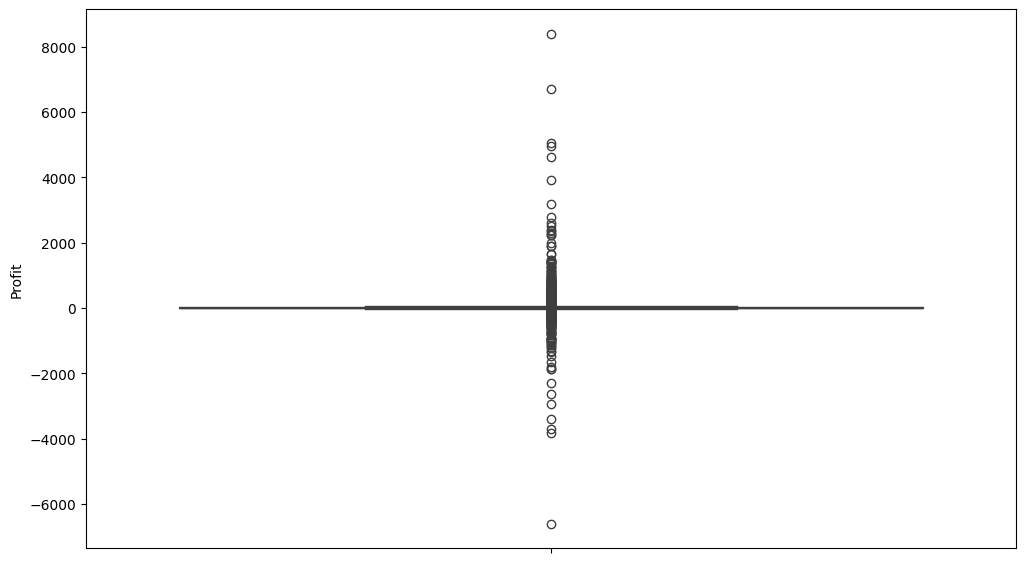

In [68]:
# Visualisai Outliers Profit Menggunakan BoxPlot

plt.figure(figsize=(12,7))
sns.boxplot(df['Profit'])
plt.show()

### `Sales`

In [69]:
# Outlier Sales
Q1_sales = df['Sales'].quantile(0.25)
Q3_sales = df['Sales'].quantile(0.75)
IQR_sales = Q3_sales - Q1_sales

batas_bawah = Q1_sales - 1.5 * IQR_sales
batas_atas = Q3_sales + 1.5 * IQR_sales

sales_outlier = df[(df['Sales'] < batas_bawah) | (df['Sales'] > batas_atas)]
display(sales_outlier.reset_index())

print(f'Batas Atas Outliers "Sales" adalah: {batas_atas:.2f}')
print(f'Batas Atas Outliers "Sales" adalah: {batas_bawah:.2f}')
print(f'Persentase dari Outliers pada Sales adalah : {(len(sales_outlier)/len(df) * 100):.2f} %')

,Row ID,Order ID,Order Date,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit
0,2,EMEA-2022-152156,2022-11-09,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,FinanceHub,QLIW57KZUV,731.9400,3,0.00,219.5820
1,4,EMEA-2021-108966,2021-10-11,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,ContactMatcher,DE9GJKGD44,957.5775,5,0.45,-383.0310
2,8,AMER-2020-115812,2020-06-09,Thomas Hodges,United States,New York City,AMER,NAMER,BNP Paribas,1065,Finance,SMB,Site Analytics,07842ES7DY,907.1520,6,0.20,90.7152
3,11,AMER-2020-115812,2020-06-09,Thomas Hodges,United States,New York City,AMER,NAMER,BNP Paribas,1065,Finance,SMB,ContactMatcher,43NZ37VE2D,1706.1840,9,0.20,85.3092
4,12,AMER-2020-115812,2020-06-09,Thomas Hodges,United States,New York City,AMER,NAMER,BNP Paribas,1065,Finance,SMB,Site Analytics,JG14MOU94R,911.4240,4,0.20,68.3568
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1162,9932,AMER-2021-104948,2021-11-13,Kimberly Newman,United States,Anaheim,AMER,NAMER,Amazon,1004,Tech,SMB,Marketing Suite,3D56KMLTYI,683.3320,4,0.15,-40.1960
1163,9943,AMER-2020-143371,2020-12-28,Carol Forsyth,United States,San Francisco,AMER,NAMER,Nestle,1089,Consumer Products,SMB,Marketing Suite - Gold,UPQPITMHDF,998.8200,9,0.00,29.9646
1164,9948,APJ-2023-121559,2023-06-02,Harry McGrath,India,Delhi,APJ,IND,Valero Energy,1093,Energy,Strategic,FinanceHub,ZTX5WHU4ZQ,1925.8800,6,0.00,539.2464
1165,9949,APJ-2023-121559,2023-06-02,Harry McGrath,India,Delhi,APJ,IND,Valero Energy,1093,Energy,Strategic,OneView,ZGTMROAYTX,2405.2000,8,0.00,793.7160


Batas Atas Outliers "Sales" adalah: 498.93
Batas Atas Outliers "Sales" adalah: -271.71
Persentase dari Outliers pada Sales adalah : 11.68 %


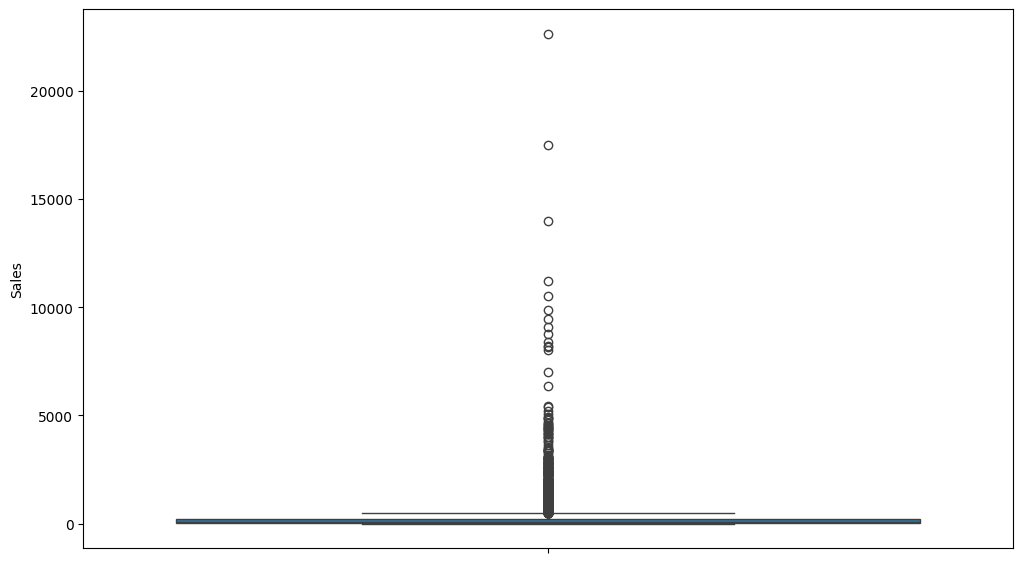

In [70]:
# Visualisai Outliers Sales Menggunakan BoxPlot

plt.figure(figsize=(12,7))
sns.boxplot(df['Sales'])
plt.show()

### `Discount`

In [71]:
# Outlier Discount
Q1_discount = df['Discount'].quantile(0.25)
Q3_discount = df['Discount'].quantile(0.75)
IQR_discount = Q3_discount - Q1_discount

batas_bawah_discount = Q1_discount - 1.5 * IQR_discount
batas_atas_discount = Q3_discount + 1.5 * IQR_discount

discount_outlier = df[(df['Discount'] < batas_bawah_discount) | (df['Discount'] > batas_atas_discount)]
display(discount_outlier.sort_values(by='Discount', ascending=False).reset_index().head(10))

print(f'Batas Atas Outliers "Discount" adalah: {batas_atas_discount:.2f}')
print(f'Batas Bawah Outliers "Discount" adalah: {batas_bawah_discount:.2f}')
print(f'Persentase dari Outliers pada Discount adalah : {(len(discount_outlier)/len(df) * 100):.2f}%')

,Row ID,Order ID,Order Date,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit
0,102,APJ-2022-158568,2022-08-30,Gavin Walsh,Australia,Sydney,APJ,ANZ,Philip Morris International,1075,Consumer Products,Enterprise,ContactMatcher,WCITXGLF0J,1.788,3,0.8,-3.0396
1,170,APJ-2020-139892,2020-09-08,Melanie Davidson,Japan,Osaka,APJ,JAPN,Nissan Motor,1098,Transportation,SMB,OneView,J7LMIXWBED,177.980,5,0.8,-453.8490
2,15,APJ-2021-118983,2021-11-22,Emily Morrison,Japan,Saitama,APJ,JAPN,Pfizer,1074,Healthcare,Enterprise,OneView,D8FGC56NNX,68.810,5,0.8,-123.8580
3,16,APJ-2021-118983,2021-11-22,Emily Morrison,Japan,Saitama,APJ,JAPN,Pfizer,1074,Healthcare,Enterprise,ContactMatcher,NRKT5R1A1G,2.544,3,0.8,-3.8160
4,175,APJ-2020-100853,2020-09-14,Gabrielle Ogden,Australia,Sydney,APJ,ANZ,Royal Dutch Shell,1031,Energy,Strategic,OneView,BTUYY86TIA,52.448,2,0.8,-131.1200
5,177,APJ-2023-152366,2023-04-22,Justin Randall,Japan,Tokyo,APJ,JAPN,Wells Fargo,1099,Finance,SMB,OneView,E5I8NPOZ23,97.264,4,0.8,-243.1600
6,9921,APJ-2022-149272,2022-03-16,Pippa Edmunds,Japan,Hiroshima,APJ,JAPN,BNP Paribas,1065,Finance,Strategic,ContactMatcher,9OC763CXCJ,22.386,7,0.8,-35.8176
7,8322,APJ-2022-149790,2022-09-27,Benjamin Hughes,Japan,Tokyo,APJ,JAPN,Apple,1008,Tech,SMB,ContactMatcher,82J0ITJZF4,15.624,2,0.8,-24.9984
8,8327,APJ-2023-103478,2023-07-22,Lillian Hodges,Australia,Melbourne,APJ,ANZ,Merck,1064,Healthcare,Strategic,ContactMatcher,BR3PJH4PEY,2.864,4,0.8,-4.5824
9,8328,APJ-2023-103478,2023-07-22,Lillian Hodges,Australia,Melbourne,APJ,ANZ,Merck,1064,Healthcare,Strategic,ContactMatcher,P9EWEEURGF,94.192,7,0.8,-164.8360


Batas Atas Outliers "Discount" adalah: 0.50
Batas Bawah Outliers "Discount" adalah: -0.30
Persentase dari Outliers pada Discount adalah : 8.57%


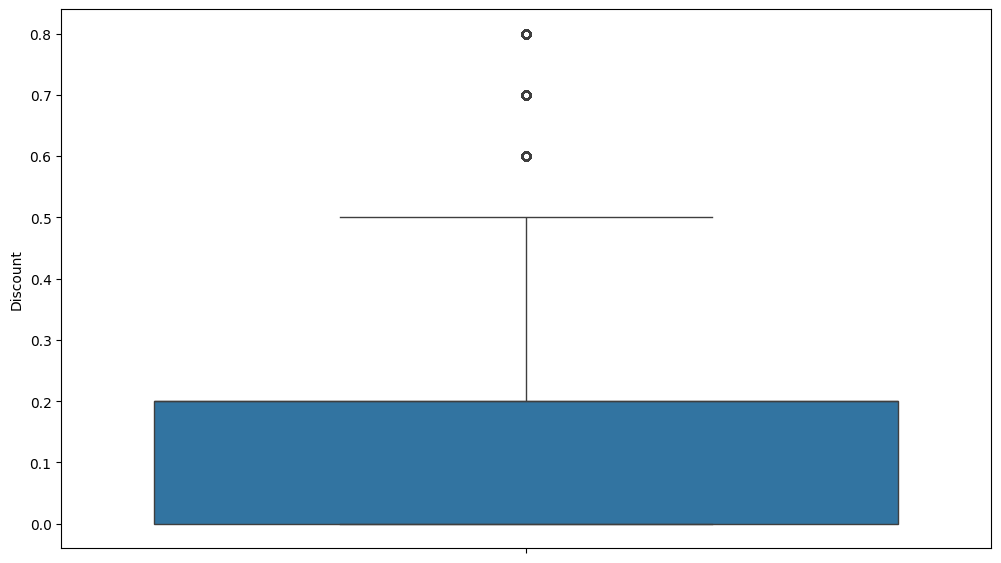

In [72]:
# Visualisai Outliers Discount Menggunakan BoxPlot

plt.figure(figsize=(12,7))
sns.boxplot(df['Discount'])
plt.show()

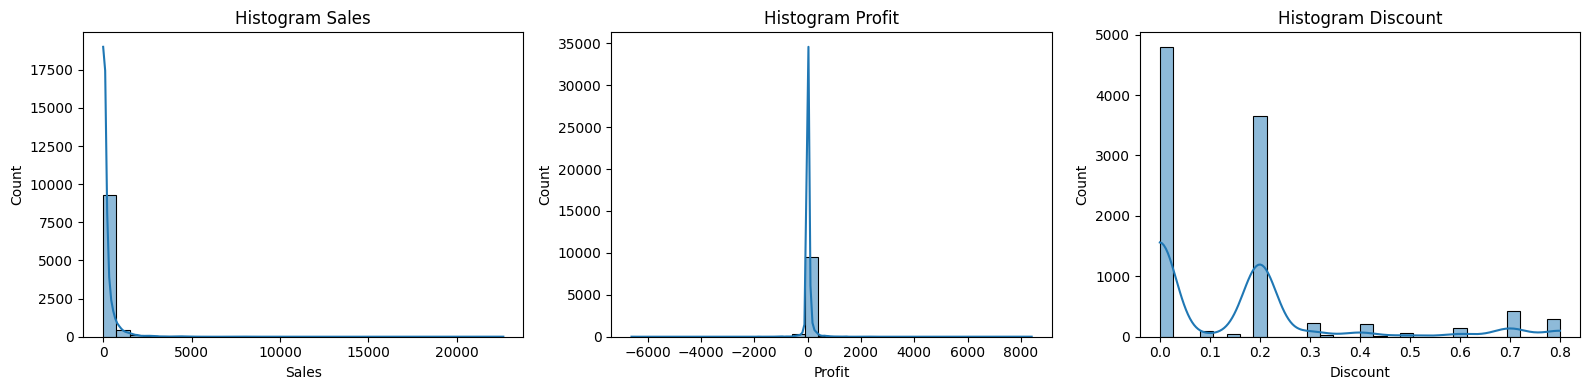

Uji Normalitas untuk Sales:
p-value: 0.0000
Tolak H0: Data TIDAK berdistribusi normal

Uji Normalitas untuk Profit:
p-value: 0.0000
Tolak H0: Data TIDAK berdistribusi normal

Uji Normalitas untuk Discount:
p-value: 0.0000
Tolak H0: Data TIDAK berdistribusi normal



In [73]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
normality_results = []
num_variables = ['Sales', 'Profit', 'Discount']

for i, var in enumerate(num_variables):
    sns.histplot(df[var], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Histogram {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Count')

    stat, p = normaltest(df[var])
    normality_results.append((var, p))

plt.tight_layout()
plt.show()

for var, p in normality_results:
    print(f'Uji Normalitas untuk {var}:')
    print(f'p-value: {p:.4f}')
    if p < 0.05:
        print('Tolak H0: Data TIDAK berdistribusi normal\n')
    else:
        print('Gagal Tolak H0: Data berdistribusi normal\n')

### **Kesimpulan**
Walau dari hasil uji normalitas menunjukkan variabel numerik (Profit, Sales, Discount) tidak berdistribusi normal (p-value < 0.05). Banyaknya outlier yang terdeteksi (IQR method) dari tiap variabel, kita menyimpulkan jika terdapat rentangan nilai yang cukup besar dari beberapa kolom seperti `Profit`, `Sales`, dan `Discount` tetapi karna ini merupakan data yang merepresentasikan transaksi bisnis maka jika kita menghilangkan data-data outlier tersebut maka dapat menghilangkan pola penting pada penentuan harga penjualan dan profitabilitas.

## Kolom Tambahan: Profit Margin

Kolom `Profit Margin` diperlukan untuk menjadi indikator utama dalam mengevaluasi tingkat profitabilitas.

In [74]:
df['Profit Margin'] = df['Profit'] / df['Sales']

df['Profit Margin'].replace([float('inf'), -float('inf')], 0, inplace=True)

df.head()

,Order ID,Order Date,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit,Profit Margin
Row ID,,,,,,,,,,,,,,,,,,
1,EMEA-2022-152156,2022-11-09,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,Marketing Suite,16GRM07R1K,261.9600,2,0.00,41.9136,0.1600
2,EMEA-2022-152156,2022-11-09,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,FinanceHub,QLIW57KZUV,731.9400,3,0.00,219.5820,0.3000
3,AMER-2022-138688,2022-06-13,Deirdre Bailey,United States,New York City,AMER,NAMER,Phillips 66,1056,Energy,Strategic,FinanceHub,JI6BVL70HQ,14.6200,2,0.00,6.8714,0.4700
4,EMEA-2021-108966,2021-10-11,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,ContactMatcher,DE9GJKGD44,957.5775,5,0.45,-383.0310,-0.4000
5,EMEA-2021-108966,2021-10-11,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,Marketing Suite - Gold,OIF7NY23WD,22.3680,2,0.20,2.5164,0.1125


## Rentangan Waktu Transaksi
Mengetahui rentang waktu penjualan membantu memahami periode data yang tersedia.

In [75]:
print(f"Periode Dataset AWS SaaS:\n- Start: {df['Order Date'].min()}\n- End: {df['Order Date'].max()}")

Periode Dataset AWS SaaS:
- Start: 2020-01-04 00:00:00
- End: 2023-12-31 00:00:00


## Data yang sudah bersih
Kita sudah selesai membersihkan data kita, sekarang, mari kita lihat sekilas informasi dari data yang sudah kita bersihkan

In [76]:
listItem = []
for col in df.columns :
    listItem.append([col, df[col].dtype, df[col].isna().sum(),
                    df[col].nunique(), list(df[col].drop_duplicates().sample(2).values)]);

dfDesc = pd.DataFrame(columns=['dataFeatures', 'dataType', 'null', 'unique', 'uniqueSample'],
                     data=listItem)
print(df.shape)
dfDesc

(9994, 18)


,dataFeatures,dataType,null,unique,uniqueSample
0,Order ID,object,0,5009,"[APJ-2023-117114, AMER-2023-105214]"
1,Order Date,datetime64[ns],0,1237,"[2022-12-14T00:00:00.000000000, 2021-04-26T00:..."
2,Contact Name,object,0,793,"[Gordon Sanderson, Jan Hemmings]"
3,Country,object,0,48,"[Ireland, Brazil]"
4,City,object,0,262,"[Detroit, Genoa]"
5,Region,object,0,3,"[AMER, EMEA]"
6,Subregion,object,0,12,"[LATAM, IND]"
7,Customer,object,0,99,"[Apple, Walmart]"
8,Customer ID,int64,0,99,"[1047, 1034]"
9,Industry,object,0,10,"[Transportation, Healthcare]"


In [ ]:
# df.to_csv('Cleaned-SaaS-Sales.csv', index=False)

# Data Analysis
Kita sudah melakukan tahap _data cleaning_. Sekarang, kita bisa mulai melakukan analisis data.  

Kita mulai analisis untuk menjawab semua _business question_ dengan tujuan untuk dapat memberikan insight dan rekomendasi kepada board of director dalam menentukan keputusan bisnis yang sebaiknya diambil untuk meningkatkan profitabilitas perusahaan.

## Analisis Tren `Sales` dan `Profit`
Analisis tren penjualan dan profit secara berkala merupakan langkah krusial untuk memahami dinamika pertumbuhan bisnis, mengenali pola musiman, serta mengidentifikasi adanya penurunan maupun peningkatan kinerja yang signifikan. Melalui pemantauan tren dari waktu ke waktu, perusahaan dapat mengambil keputusan strategis yang berbasis data, seperti menentukan waktu yang tepat untuk melakukan promosi, mengantisipasi potensi penurunan penjualan, serta mengevaluasi efektivitas strategi bisnis yang telah diterapkan.

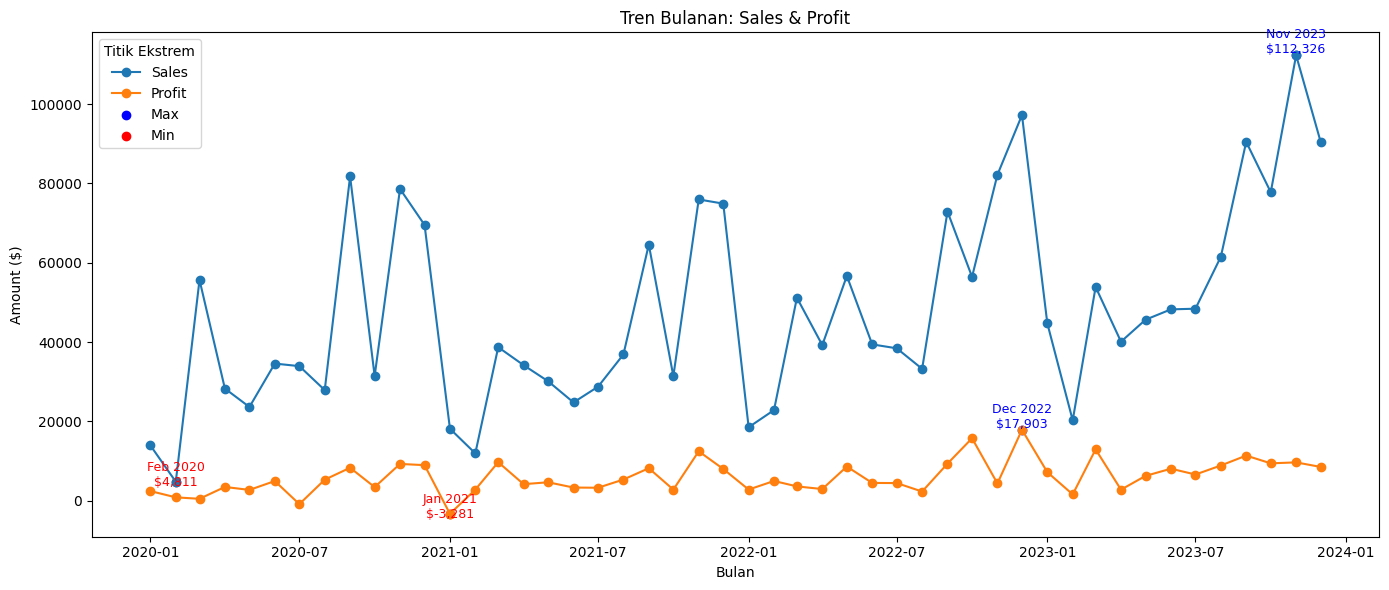

In [78]:
# Ekstraksi waktu
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.to_period('Q')

# Agregasi bulanan
monthly_trend = df.groupby(df['Order Date'].dt.to_period('M')).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).reset_index()
monthly_trend['Order Date'] = monthly_trend['Order Date'].dt.to_timestamp()

# Agregasi tahunan
yearly_trend = df.groupby('Year').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).reset_index()

# Plot Tren Bulanan Sales & Profit
plt.figure(figsize=(14, 6))
plt.plot(monthly_trend['Order Date'], monthly_trend['Sales'], marker='o', label='Sales')
plt.plot(monthly_trend['Order Date'], monthly_trend['Profit'], marker='o', label='Profit')

# Titik tertinggi & terendah Sales
max_sales_idx = monthly_trend['Sales'].idxmax()
min_sales_idx = monthly_trend['Sales'].idxmin()
plt.scatter(monthly_trend.loc[max_sales_idx, 'Order Date'], monthly_trend.loc[max_sales_idx, 'Sales'],
            color='blue', label='Max')
plt.scatter(monthly_trend.loc[min_sales_idx, 'Order Date'], monthly_trend.loc[min_sales_idx, 'Sales'],
            color='red', label='Min')

plt.text(monthly_trend.loc[max_sales_idx, 'Order Date'],
         monthly_trend.loc[max_sales_idx, 'Sales'] + 500,
         f"{monthly_trend.loc[max_sales_idx, 'Order Date'].strftime('%b %Y')}\n${monthly_trend.loc[max_sales_idx, 'Sales']:,.0f}",
         ha='center', color='blue', fontsize=9)

plt.text(monthly_trend.loc[min_sales_idx, 'Order Date'],
         monthly_trend.loc[min_sales_idx, 'Sales'] - 1000,
         f"{monthly_trend.loc[min_sales_idx, 'Order Date'].strftime('%b %Y')}\n${monthly_trend.loc[min_sales_idx, 'Sales']:,.0f}",
         ha='center', color='red', fontsize=9)

# Titik tertinggi & terendah Profit
max_profit_idx = monthly_trend['Profit'].idxmax()
min_profit_idx = monthly_trend['Profit'].idxmin()
plt.scatter(monthly_trend.loc[max_profit_idx, 'Order Date'], monthly_trend.loc[max_profit_idx, 'Profit'],
            color='blue')
plt.scatter(monthly_trend.loc[min_profit_idx, 'Order Date'], monthly_trend.loc[min_profit_idx, 'Profit'],
            color='red')

plt.text(monthly_trend.loc[max_profit_idx, 'Order Date'],
         monthly_trend.loc[max_profit_idx, 'Profit'] + 500,
         f"{monthly_trend.loc[max_profit_idx, 'Order Date'].strftime('%b %Y')}\n${monthly_trend.loc[max_profit_idx, 'Profit']:,.0f}",
         ha='center', color='blue', fontsize=9)

plt.text(monthly_trend.loc[min_profit_idx, 'Order Date'],
         monthly_trend.loc[min_profit_idx, 'Profit'] - 1000,
         f"{monthly_trend.loc[min_profit_idx, 'Order Date'].strftime('%b %Y')}\n${monthly_trend.loc[min_profit_idx, 'Profit']:,.0f}",
         ha='center', color='red', fontsize=9)

# Finalisasi plot
plt.title('Tren Bulanan: Sales & Profit')
plt.xlabel('Bulan')
plt.ylabel('Amount ($)')
plt.legend(title='Titik Ekstrem')
plt.tight_layout()
plt.show()

Insight:

- Penjualan meningkat tiap akhir tahun di mana awal tahun penjualan turun dan ada lonjakan penjualan yang signifikan di akhir 2023 – Penjualan melonjak drastis pada **Nov 2023 ($112K)**. Kemungkinan dipicu oleh strategi akhir tahun seperti discount, campaign besar, atau peluncuran produk baru.

- Meski sales tinggi di 2023, profit belum tentu mengikuti (grafik profit tidak disebutkan nilainya). Perlu dicek apakah kenaikan sales berasal dari diskon besar yang menggerus margin.

Catatan: perlu analisis membandingkan dengan data profit, sales tinggi ≠ sehat jika margin turun drastis.

Berikut kita akan melihat total profit tiap tahun, kapan waktu profit minus atau merugi, dan proporsi untung rugi per tahun

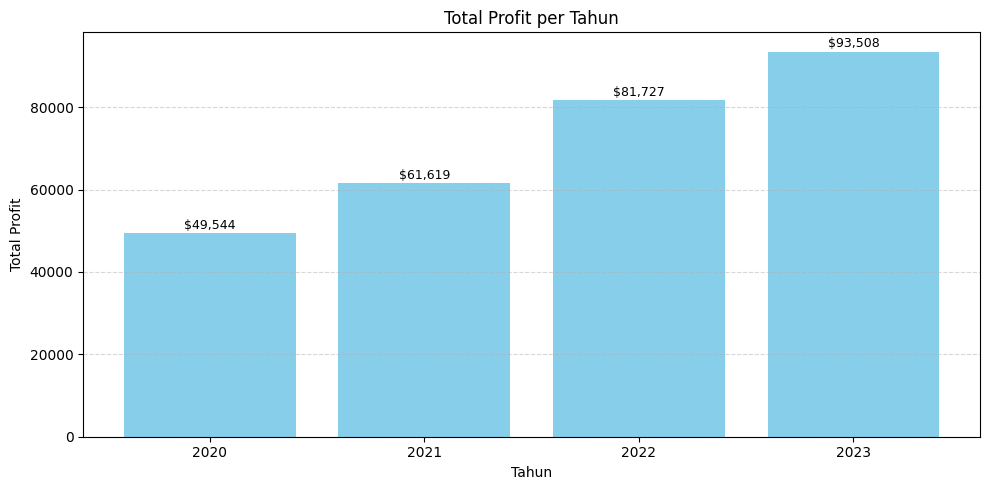

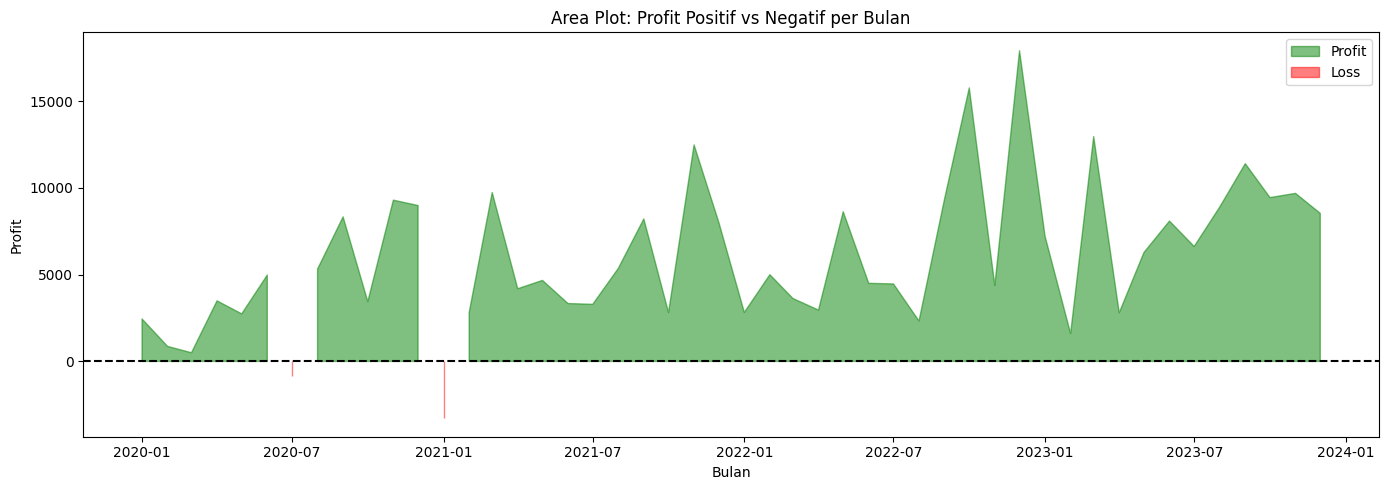

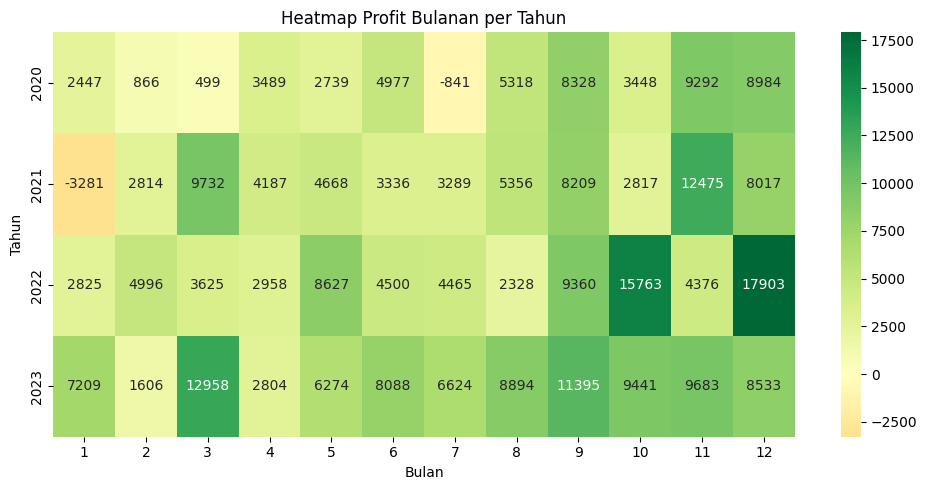

Periode dengan profit negatif (rugi):


,Order Date,Profit
6,2020-07-01,-841.4826
12,2021-01-01,-3281.0070


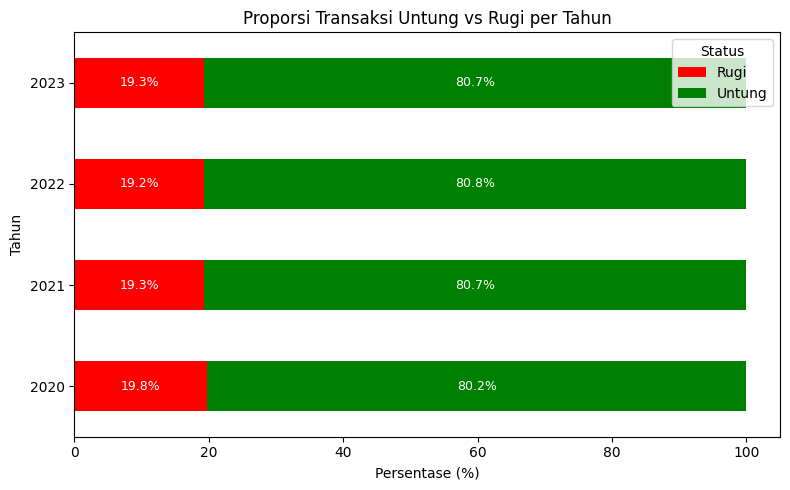

In [79]:
# Bar chart
plt.figure(figsize=(10, 5))
bars = plt.bar(yearly_trend['Year'].astype(str), yearly_trend['Profit'], color='skyblue')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1000, f"${yval:,.0f}", ha='center', fontsize=9)

plt.title('Total Profit per Tahun')
plt.ylabel('Total Profit')
plt.xlabel('Tahun')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# Area plot: profit positif vs negatif per bulan
plt.figure(figsize=(14, 5))
plt.fill_between(monthly_trend['Order Date'], monthly_trend['Profit'], where=monthly_trend['Profit']>=0, color='green', alpha=0.5, label='Profit')
plt.fill_between(monthly_trend['Order Date'], monthly_trend['Profit'], where=monthly_trend['Profit']<0, color='red', alpha=0.5, label='Loss')
plt.axhline(0, color='black', linestyle='--')
plt.title('Area Plot: Profit Positif vs Negatif per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Profit')
plt.legend()
plt.tight_layout()
plt.show()

# Heatmap musiman: profit per bulan vs tahun
pivot = df.pivot_table(index='Year', columns='Month', values='Profit', aggfunc='sum')
plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn', center=0)
plt.title('Heatmap Profit Bulanan per Tahun')
plt.ylabel('Tahun')
plt.xlabel('Bulan')
plt.tight_layout()
plt.show()

# Identifikasi periode rugi (profit negatif)
loss_periods = monthly_trend[monthly_trend['Profit'] < 0]
print("Periode dengan profit negatif (rugi):")
display(loss_periods[['Order Date', 'Profit']])

# Proporsi transaksi untung vs rugi per tahun
df['Profit_Positive'] = df['Profit'] > 0
profit_prop = df.groupby(['Year', 'Profit_Positive']).size().unstack(fill_value=0)
profit_prop_pct = profit_prop.div(profit_prop.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 5))
profit_prop_pct.plot(kind='barh', stacked=True, color=['red', 'green'], ax=ax)
for i, year in enumerate(profit_prop_pct.index):
    for j, val in enumerate(profit_prop_pct.loc[year]):
        ax.text(val/2 + profit_prop_pct.iloc[i, :j].sum(), i, f"{val:.1f}%", va='center', ha='center', color='white', fontsize=9)
plt.title('Proporsi Transaksi Untung vs Rugi per Tahun')
plt.xlabel('Persentase (%)')
plt.ylabel('Tahun')
plt.legend(['Rugi', 'Untung'], title='Status')
plt.tight_layout()
plt.show()

Insight:

- Profit perusahaan secara tahunan mengalami tren kenaikan signifikan, dengan **profit tertinggi pada tahun 2023 (Rp93.507K)**, menunjukkan pertumbuhan bisnis yang positif.
- Area plot profit bulanan memperlihatkan sebagian besar bulan menghasilkan profit positif, namun terdapat beberapa periode rugi, terutama pada awal tahun 2021 dan pertengahan 2020. Hal ini bisa disebabkan faktor musiman atau strategi diskon/promosi tertentu.
- Heatmap profit bulanan per tahun menegaskan adanya fluktuasi profit antar bulan dan tahun. Profit tertinggi biasanya terjadi di akhir tahun (Q4), sedangkan kerugian cenderung muncul di awal tahun.
- Proporsi transaksi untung vs rugi per tahun relatif stabil: sekitar 80% transaksi menghasilkan profit, dan 20% mengalami kerugian. Rasio ini konsisten dari tahun ke tahun, menandakan manajemen risiko yang cukup baik.
- Secara keseluruhan, bisnis menunjukkan pertumbuhan profit yang sehat, namun tetap perlu diwaspadai periode rugi musiman dan transaksi dengan margin negatif agar profitabilitas tetap optimal.

## Analisis Penjualan & Profitabilitas Berdasarkan `Subregion`

Dataset ini menyediakan tiga tingkat detail geografis: `Region`, `Subregion`, dan `Country`. Di antara ketiganya, `Subregion` yang paling bermakna untuk analisis. Mengapa `Subregion`?

- `Region` hanya memiliki tiga kategori (EMEA, AMER, APJ). Meskipun dapat digunakan untuk *high-level overview*, tingkat ini terlalu luas untuk menangkap perbedaan kinerja pasar secara signifikan. Setiap `Region` mencakup banyak negara dengan karakteristik dan perilaku pelanggan yang sangat beragam, sehingga berpotensi menghilangkan pola-pola penting.

- Sebaliknya, `Country` memiliki 48 kategori yang terlalu rinci untuk analisis yang jelas dan efektif. Penggunaan data pada level country cenderung menghasilkan tabel dan visualisasi yang padat, sementara beberapa negara mungkin memiliki jumlah transaksi yang terlalu sedikit untuk menghasilkan insight yang reliabel. Hal ini dapat menimbulkan *statistical noise* dan mempersulit identifikasi tren yang relevan bagi bisnis.

- `Subregion` menawarkan keseimbangan yang optimal, dengan 12 kategori. Tingkat ini cukup detail untuk mengungkap perbedaan kinerja pasar, namun tetap mudah dikelola dalam visualisasi. Dengan `Subregion`, kita dapat mengidentifikasi kelompok pasar yang menunjukkan penjualan kuat, profitabilitas rendah, atau ketergantungan tinggi terhadap diskon.

Berdasarkan pertimbangan tersebut, Subregion merupakan dimensi geografis yang paling tepat untuk memahami kinerja pasar perusahaan sekaligus mengidentifikasi area yang berpotensi untuk peningkatan profitabilitas.

Analisis ini bertujuan untuk menjawab pertanyaan bisnis berikut: "`Subregion` mana yang menunjukkan performa sales dan profitabilitas yang kuat atau lemah?”

### Total `Sales` dan `Profit` Berdasarkan `Subregion`

In [24]:
subregion = df.groupby('Subregion')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
subregion

,Sales,Profit
Subregion,,
NAMER,596328.9015,109784.0388
EU-WEST,384065.6140,26706.6029
UKIR,347468.0210,85238.2452
LATAM,241520.7030,17642.9510
JAPN,170188.0458,-25729.3563
NOR,127326.9600,16044.7604
APAC,106771.2120,30311.1778
ANZ,84949.6230,-11450.7709
MEA,76793.6960,7200.1468


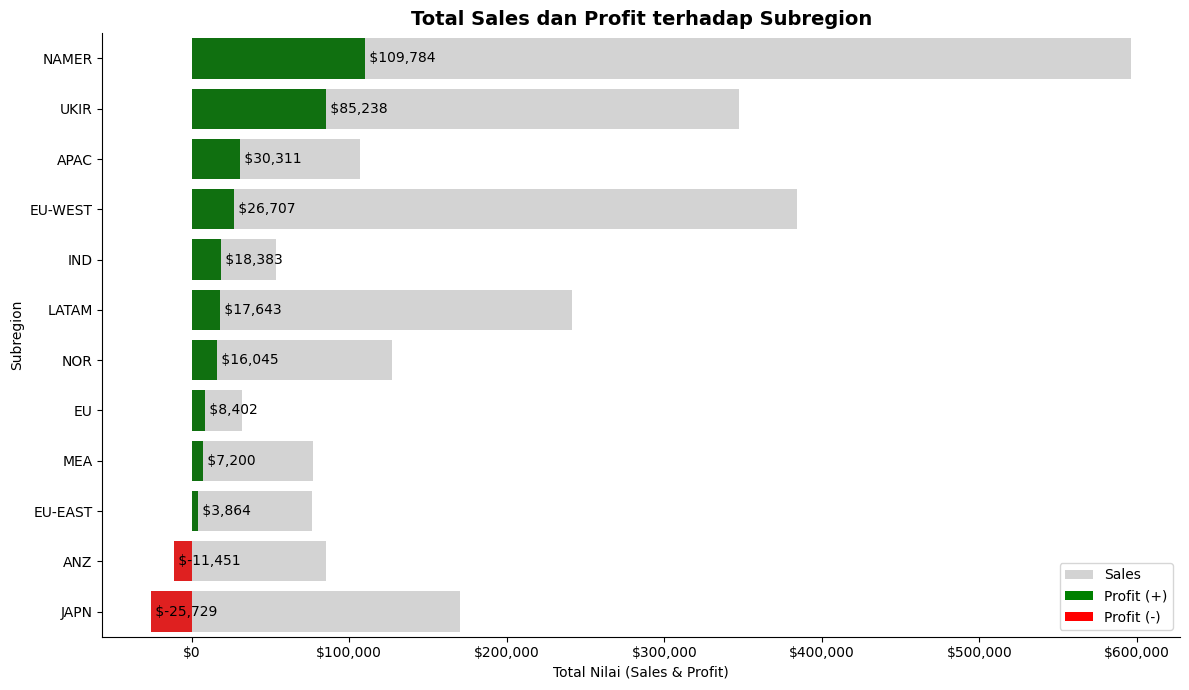

In [25]:
# Aggregation
agg_df = df.groupby('Subregion').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()

# Sort berdasarkan Profit
agg_df = agg_df.sort_values(by='Profit', ascending=False)

# Formatter dollar
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Plot
plt.figure(figsize=(12, 7))

# Barplot Sales
sns.barplot(
    x='Sales',
    y='Subregion',
    data=agg_df,
    color='lightgray'
)

# Warna profit
profit_colors = ['red' if x < 0 else 'green' for x in agg_df['Profit']]

# Overlay Profit
sns.barplot(
    x='Profit',
    y='Subregion',
    data=agg_df,
    palette=profit_colors
)

# Judul
plt.title('Total Sales dan Profit terhadap Subregion', fontsize=14, weight='bold')

# Label
plt.xlabel('Total Nilai (Sales & Profit)')
plt.ylabel('Subregion')

# Format axis jadi dollar
plt.gca().xaxis.set_major_formatter(FuncFormatter(dollar_format))

# Annotasi profit (pakai dollar)
for i, v in enumerate(agg_df['Profit']):
    plt.text(v, i, f' ${v:,.0f}', va='center')

# Custom legend
legend_elements = [
    Patch(facecolor='lightgray', label='Sales'),
    Patch(facecolor='green', label='Profit (+)'),
    Patch(facecolor='red', label='Profit (-)')
]

plt.legend(handles=legend_elements)

sns.despine()
plt.tight_layout()

Interpretasi:

- `NAMER` merupakan pasar terbesar sekaligus **paling menguntungkan**, diikuti oleh UKIR.
- Sebaliknya, `JAPN` dan `ANZ` menunjukkan **profit berada pada tingkat negatif**.

### Rata-Rata `Profit Margin` Berdasarkan `Subregion`

In [26]:
subregion_profit_margin = df.groupby('Subregion')['Profit Margin'].mean().sort_values(ascending=False)
subregion_profit_margin

Subregion
IND        0.347852
APAC       0.336265
EU         0.317909
UKIR       0.302176
NAMER      0.277934
MEA        0.176588
NOR        0.169609
LATAM      0.090615
EU-EAST    0.090362
EU-WEST    0.071539
JAPN      -0.342011
ANZ       -0.343492
Name: Profit Margin, dtype: float64

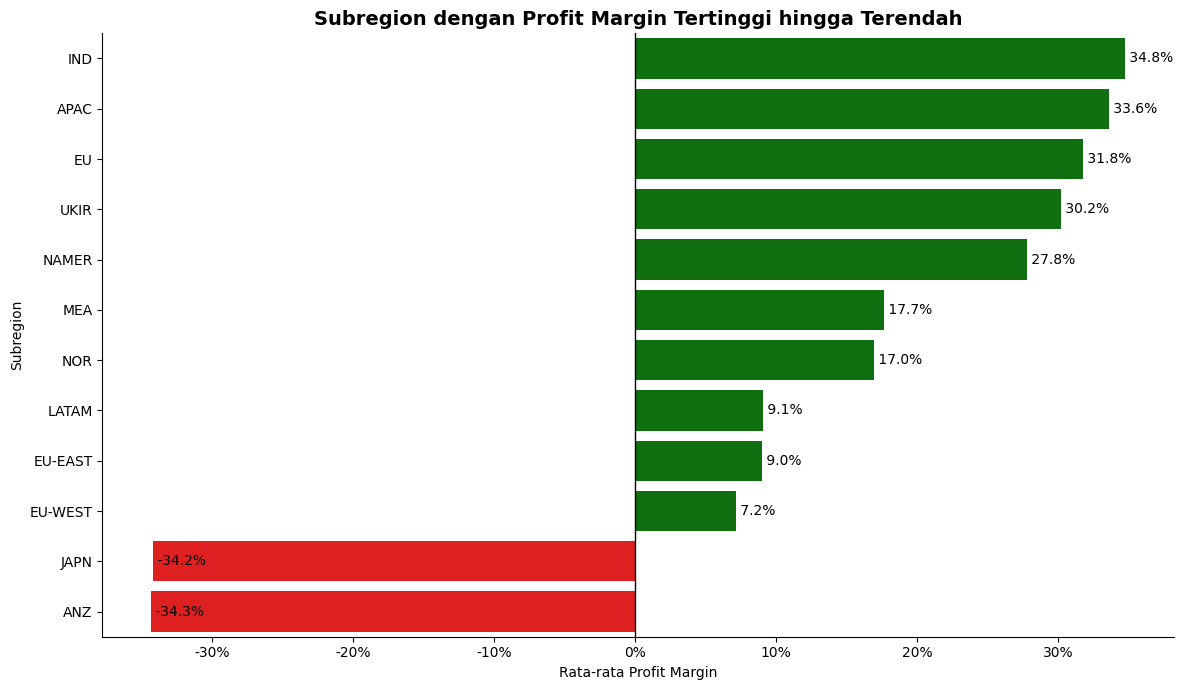

In [27]:
# Aggregation
subregion_profit_margin = df.groupby('Subregion')['Profit Margin'].mean().reset_index()

# Sort
subregion_profit_margin = subregion_profit_margin.sort_values(
    by='Profit Margin', ascending=False
)

# Warna berdasarkan value
colors = ['green' if x > 0 else 'red' for x in subregion_profit_margin['Profit Margin']]

# Formatter persen
def percent_format(x, pos):
    return f'{x:.0%}'

# Plot
plt.figure(figsize=(12, 7))

sns.barplot(
    x='Profit Margin',
    y='Subregion',
    data=subregion_profit_margin,
    palette=colors
)

# Judul (lebih storytelling)
plt.title('Subregion dengan Profit Margin Tertinggi hingga Terendah', 
          fontsize=14, weight='bold')

# Label
plt.xlabel('Rata-rata Profit Margin')
plt.ylabel('Subregion')

# Format axis ke persen
plt.gca().xaxis.set_major_formatter(FuncFormatter(percent_format))

# Garis tengah (0) untuk highlight rugi vs untung
plt.axvline(0, color='black', linewidth=1)

# Annotasi
for i, v in enumerate(subregion_profit_margin['Profit Margin']):
    plt.text(v, i, f' {v:.1%}', va='center')

sns.despine()
plt.tight_layout()

plt.show()

Interpretasi:

- `IND` memiliki **margin tertinggi**, namun dengan **tingkat sales yang rendah**.
- `APAC`, `EU`, `UKIR`, dan `NAMER` menunjukkan efisiensi yang baik serta memiliki sales yang cukup solid.
- Sebaliknya, `JAPN` dan `ANZ` memiliki **margin negatif**, yang berarti secara rata-rata mengalami kerugian pada setiap transaksi.

### Visualisasi Distribusi `Profit Margin` Berdasarkan `Subregion`

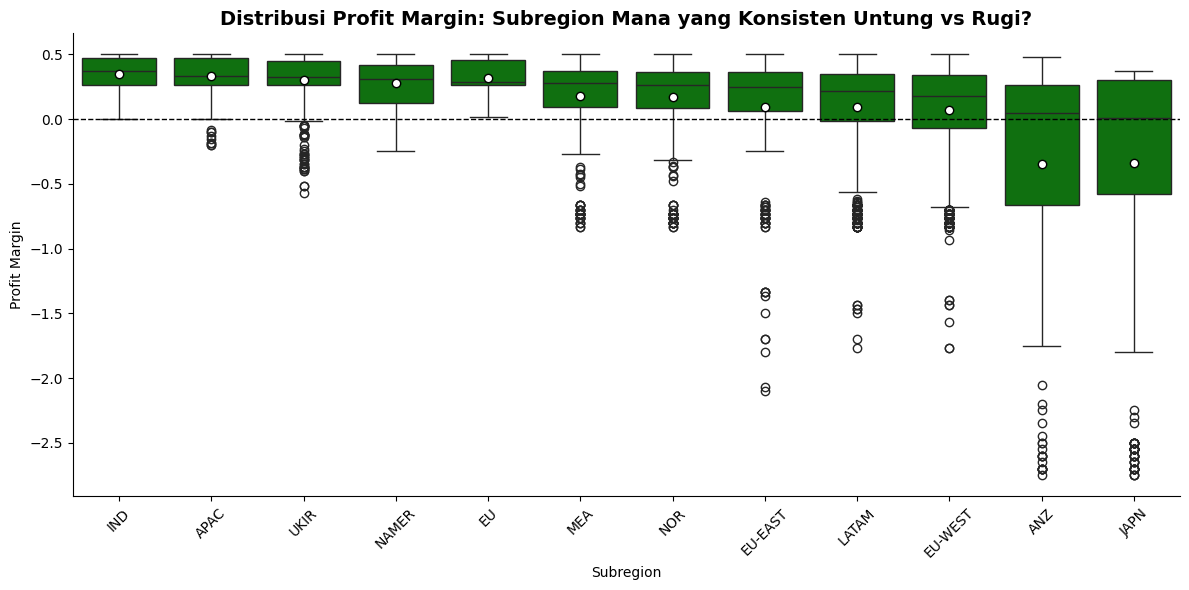

In [28]:
# Urutkan berdasarkan median profit margin
order = df.groupby('Subregion')['Profit Margin'].median().sort_values(ascending=False).index

# Warna berdasarkan median
median_values = df.groupby('Subregion')['Profit Margin'].median()
colors = ['green' if median_values[sub] > 0 else 'red' for sub in order]

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='Subregion',
    y='Profit Margin',
    order=order,
    palette=colors,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 6
    }
)

# Garis break-even
plt.axhline(0, color='black', linestyle='--', linewidth=1)

# Judul lebih storytelling
plt.title('Distribusi Profit Margin: Subregion Mana yang Konsisten Untung vs Rugi?',
          fontsize=14, weight='bold')

# Label
plt.xlabel('Subregion')
plt.ylabel('Profit Margin')

# Rotasi label
plt.xticks(rotation=45)

sns.despine()
plt.tight_layout()

Dalam setiap *boxplot*, kotak merepresentasikan 50% nilai tengah (middle 50%), garis menunjukkan nilai median, dan titik-titik merepresentasikan nilai margin yang sangat tinggi atau sangat rendah (outliers).

Interpretasi:

**IND, APAC, UKIR, dan EU:**

- Memiliki median profit margin yang tinggi.
- Distribusi relatif rapat (tight distribution), menunjukkan konsistensi kinerja.

**JAPN dan ANZ:**

- Memiliki sebaran yang sangat lebar.
- Terdapat banyak outliers negatif yang signifikan.
- Median profit margin berada di sekitar atau mendekati nol.

### Ringkasan `Sales`, `Profit`, dan `Profit Margin` Berdasarkan `Subregion`

In [29]:
subregion_summary = df.groupby('Subregion').agg({
    'Sales':'sum',
    'Profit':'sum',
    'Profit Margin':'mean'
}).sort_values('Sales', ascending=False)

subregion_summary

,Sales,Profit,Profit Margin
Subregion,,,
NAMER,596328.9015,109784.0388,0.277934
EU-WEST,384065.6140,26706.6029,0.071539
UKIR,347468.0210,85238.2452,0.302176
LATAM,241520.7030,17642.9510,0.090615
JAPN,170188.0458,-25729.3563,-0.342011
NOR,127326.9600,16044.7604,0.169609
APAC,106771.2120,30311.1778,0.336265
ANZ,84949.6230,-11450.7709,-0.343492
MEA,76793.6960,7200.1468,0.176588


Insight `Subregion`:

Hasil analisis menunjukkan bahwa sales dan profitabilitas bervariasi secara signifikan antar subregion. `NAMER` merupakan **pasar terbesar perusahaan dari sisi pendapatan** ($596K USD) dan juga menghasilkan profit yang kuat. Sementara itu, `UKIR`, `APAC`, `IND`, dan `EU` menunjukkan **profit margin yang sehat**, mencerminkan kinerja pasar yang stabil dan efisien.

Sebaliknya, terdapat beberapa subregion dengan kontribusi sales tinggi namun profitabilitas yang relatif lemah. `EU-WEST` menghasilkan **pendapatan tertinggi kedua**, tetapi memiliki rata-rata profit margin yang sangat rendah (7%), yang mengindikasikan adanya *heavy discounting* atau dominasi pelanggan dengan margin rendah.

Temuan yang paling mengkhawatirkan adalah bahwa `JAPN` dan `ANZ` memiliki **rata-rata profit margin negatif**, yang berarti **perusahaan mengalami kerugian** pada transaksi di pasar tersebut. Hal ini juga dikonfirmasi oleh *boxplot* yang menunjukkan variabilitas margin yang luas serta banyaknya outliers dengan margin negatif.

Secara keseluruhan, analisis ini menunjukkan bahwa profitabilitas perusahaan tidak konsisten di berbagai subregion. Beberapa pasar menunjukkan kinerja yang stabil dan efisien, sementara yang lain menghadapi margin rendah bahkan kerugian. Temuan ini menegaskan perlunya **perbaikan strategi pricing dan discount yang lebih terarah**, khususnya pada subregion dengan kinerja yang kurang optimal.

## Analisis Penjualan & Profitabilitas Berdasarkan `Segment` Pelanggan dan `Industry`

Setelah memahami berdasarkan `Subregion`, langkah berikutnya adalah menganalisis karakteristik pelanggan untuk mengetahui tipe pelanggan mana yang paling berkontribusi terhadap profitabilitas perusahaan. Dataset ini memiliki dua atribut penting untuk tujuan tersebut:

- `Segment` (SMB, Enterprise, Strategic)
- `Industry` (Finance, Tech, Healthcare, dan lainnya)

`Segment` pelanggan memberikan *high-level grouping* berdasarkan jenis bisnis, sementara `Industry` menyediakan rincian yang lebih spesifik. Kombinasi kedua dimensi ini membantu dalam menjawab pertanyaan bisnis berikut:

“Customer `Segment` dan `Industry` mana yang memberikan kontribusi profit terbesar maupun terkecil?”

### Total `Sales` dan `Profit` Berdasarkan `Segment`

In [30]:
segment = df.groupby('Segment')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
segment

,Sales,Profit
Segment,,
SMB,1.161401e+06,134119.2092
Strategic,7.061464e+05,91979.1340
Enterprise,4.296531e+05,60298.6785


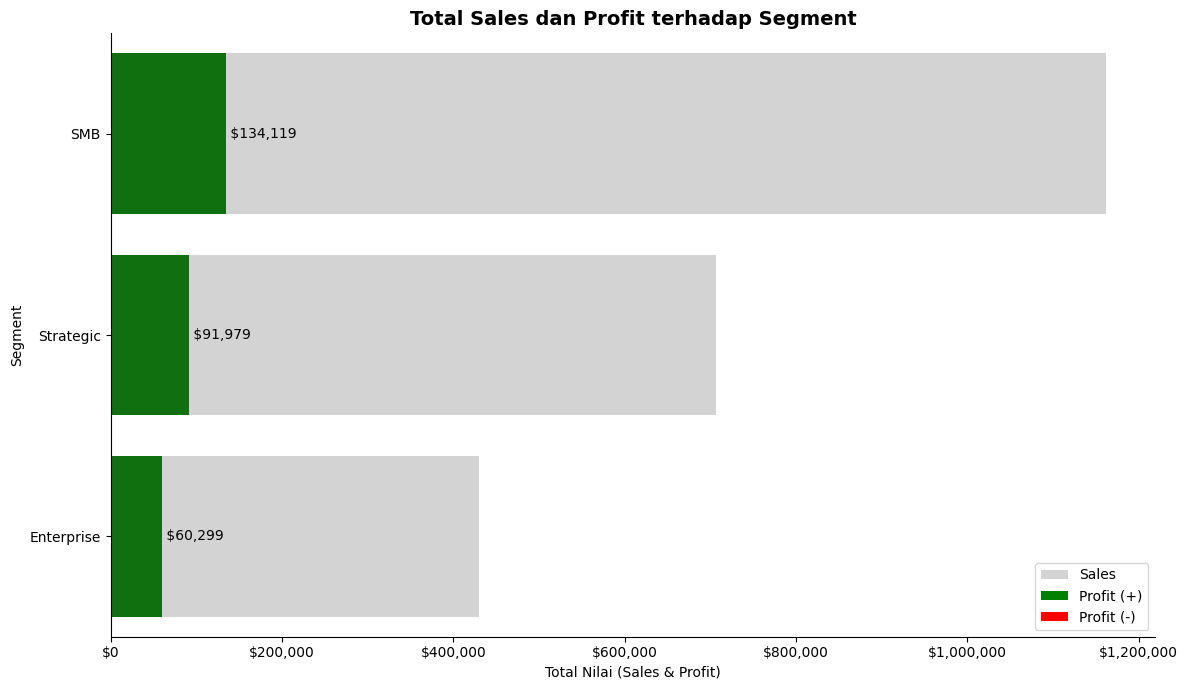

In [31]:
# Aggregation
agg_df = df.groupby('Segment').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()

# Sort berdasarkan Profit
agg_df = agg_df.sort_values(by='Profit', ascending=False)

# Formatter dollar
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Plot
plt.figure(figsize=(12, 7))

# Barplot Sales
sns.barplot(
    x='Sales',
    y='Segment',
    data=agg_df,
    color='lightgray'
)

# Warna profit
profit_colors = ['red' if x < 0 else 'green' for x in agg_df['Profit']]

# Overlay Profit
sns.barplot(
    x='Profit',
    y='Segment',
    data=agg_df,
    palette=profit_colors
)

# Judul
plt.title('Total Sales dan Profit terhadap Segment', fontsize=14, weight='bold')

# Label
plt.xlabel('Total Nilai (Sales & Profit)')
plt.ylabel('Segment')

# Format axis jadi dollar
plt.gca().xaxis.set_major_formatter(FuncFormatter(dollar_format))

# Annotasi profit (pakai dollar)
for i, v in enumerate(agg_df['Profit']):
    plt.text(v, i, f' ${v:,.0f}', va='center')

# Custom legend
legend_elements = [
    Patch(facecolor='lightgray', label='Sales'),
    Patch(facecolor='green', label='Profit (+)'),
    Patch(facecolor='red', label='Profit (-)')
]

plt.legend(handles=legend_elements)

sns.despine()
plt.tight_layout()

Interpretasi:

`SMB` merupakan **kontributor terbesar terhadap revenue dan profit**, dengan menghasilkan sales sekitar **2–3 kali lebih tinggi** dibandingkan segmen lainnya.

### Rata-Rata `Profit Margin` Berdasarkan `Segment`

In [32]:
segment_profit_margin = df.groupby('Segment')['Profit Margin'].mean().sort_values(ascending=False)
segment_profit_margin

Segment
Enterprise    0.142870
Strategic     0.121203
SMB           0.112050
Name: Profit Margin, dtype: float64

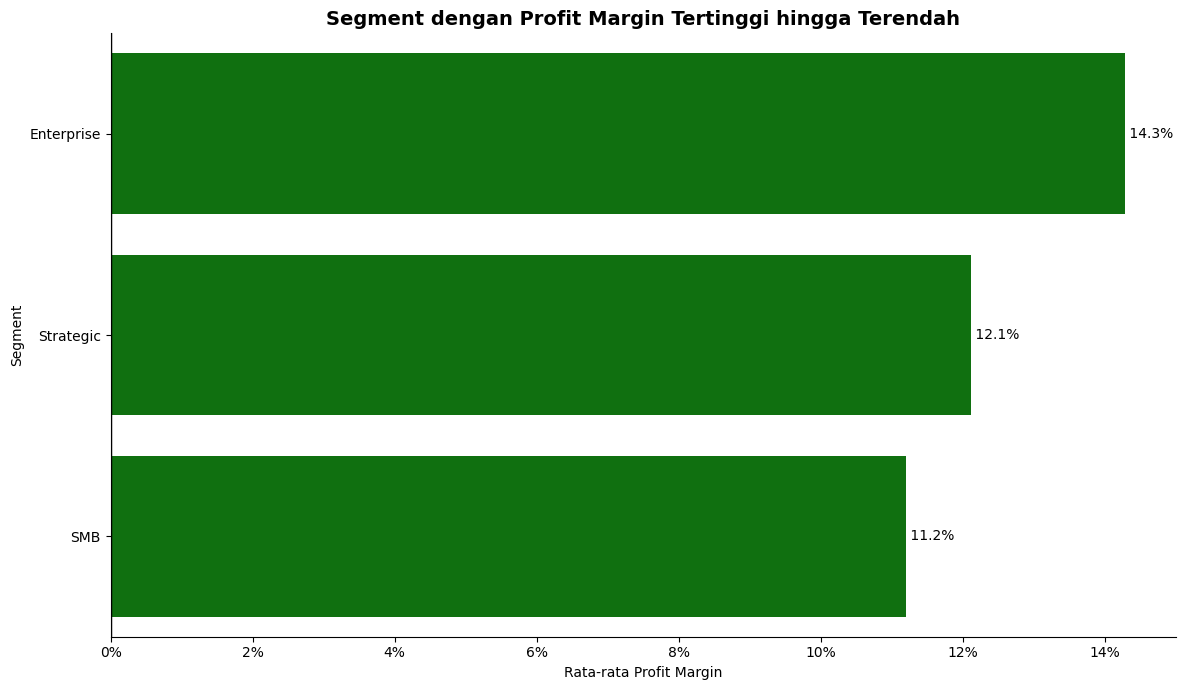

In [33]:
# Aggregation
segment_profit_margin = df.groupby('Segment')['Profit Margin'].mean().reset_index()

# Sort
segment_profit_margin = segment_profit_margin.sort_values(
    by='Profit Margin', ascending=False
)

# Warna berdasarkan value
colors = ['green' if x > 0 else 'red' for x in segment_profit_margin['Profit Margin']]

# Formatter persen
def percent_format(x, pos):
    return f'{x:.0%}'

# Plot
plt.figure(figsize=(12, 7))

sns.barplot(
    x='Profit Margin',
    y='Segment',
    data=segment_profit_margin,
    palette=colors
)

# Judul (lebih storytelling)
plt.title('Segment dengan Profit Margin Tertinggi hingga Terendah', 
          fontsize=14, weight='bold')

# Label
plt.xlabel('Rata-rata Profit Margin')
plt.ylabel('Segment')

# Format axis ke persen
plt.gca().xaxis.set_major_formatter(FuncFormatter(percent_format))

# Garis tengah (0) untuk highlight rugi vs untung
plt.axvline(0, color='black', linewidth=1)

# Annotasi
for i, v in enumerate(segment_profit_margin['Profit Margin']):
    plt.text(v, i, f' {v:.1%}', va='center')

sns.despine()
plt.tight_layout()

plt.show()

Interpretasi:

- Pelanggan `Enterprise` merupakan yang **paling menguntungkan**, kemungkinan karena mereka membeli produk bernilai tinggi dengan margin yang lebih stabil.
- Sebaliknya, `SMB` memiliki **margin terendah**, yang mengindikasikan kecenderungan membeli produk dengan margin rendah serta membutuhkan discounting yang lebih agresif.

Interpretasi untuk Customer Segment:

Konsentrasi revenue yang tinggi pada `SMB` yang disertai dengan profit margin yang lebih rendah menunjukkan adanya tekanan harga pada segmen ini. Sementara itu, pelanggan `Enterprise`, meskipun jumlahnya lebih sedikit, memberikan efisiensi yang lebih tinggi serta stabilitas margin yang lebih baik.

### Total `Sales` dan `Profit` Berdasarkan `Industry`

In [34]:
industry = df.groupby('Industry')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
industry

,Sales,Profit
Industry,,
Finance,474150.4844,50348.9696
Energy,304644.1409,45282.3137
Manufacturing,295192.3812,38413.1064
Healthcare,273183.2882,31969.0932
Tech,263169.0277,24615.0436
Consumer Products,224044.1422,37018.0077
Retail,223072.0720,30207.8208
Communications,120962.2365,13976.3410
Transportation,90191.3276,7402.6967


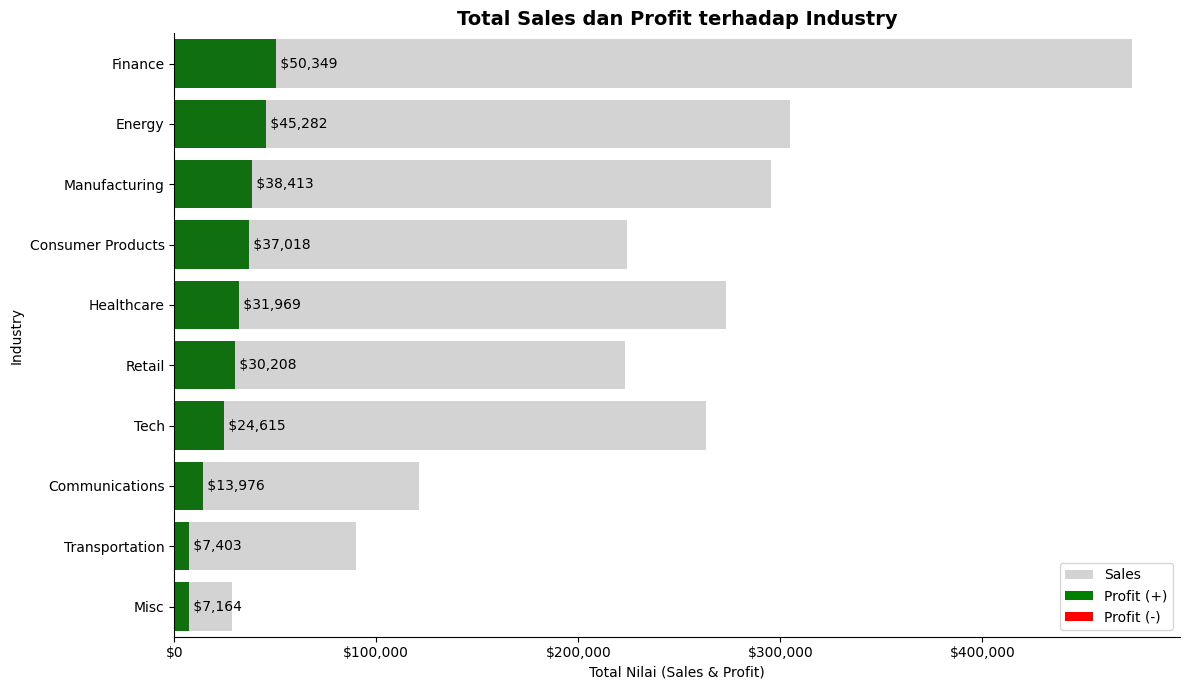

In [35]:
# Aggregation
agg_df = df.groupby('Industry').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()

# Sort berdasarkan Profit
agg_df = agg_df.sort_values(by='Profit', ascending=False)

# Formatter dollar
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Plot
plt.figure(figsize=(12, 7))

# Barplot Sales
sns.barplot(
    x='Sales',
    y='Industry',
    data=agg_df,
    color='lightgray'
)

# Warna profit
profit_colors = ['red' if x < 0 else 'green' for x in agg_df['Profit']]

# Overlay Profit
sns.barplot(
    x='Profit',
    y='Industry',
    data=agg_df,
    palette=profit_colors
)

# Judul
plt.title('Total Sales dan Profit terhadap Industry', fontsize=14, weight='bold')

# Label
plt.xlabel('Total Nilai (Sales & Profit)')
plt.ylabel('Industry')

# Format axis jadi dollar
plt.gca().xaxis.set_major_formatter(FuncFormatter(dollar_format))

# Annotasi profit (pakai dollar)
for i, v in enumerate(agg_df['Profit']):
    plt.text(v, i, f' ${v:,.0f}', va='center')

# Custom legend
legend_elements = [
    Patch(facecolor='lightgray', label='Sales'),
    Patch(facecolor='green', label='Profit (+)'),
    Patch(facecolor='red', label='Profit (-)')
]

plt.legend(handles=legend_elements)

sns.despine()
plt.tight_layout()

Interpretasi:

- `Finance` merupakan industri terbesar sekaligus kontributor profit yang kuat.
- Di bawahnya, `Energy` dan `Manufacturing` juga memberikan kontribusi revenue dan profit yang signifikan.
- Sementara itu, industri `Misc`, `Transportation`, dan `Communications` tergolong sebagai niche markets dengan total sales yang relatif rendah.

### Rata-Rata `Profit Margin` Berdasarkan `Industry`

In [36]:
industry_profit_margin = df.groupby('Industry')['Profit Margin'].mean().sort_values(ascending=False)
industry_profit_margin

Industry
Misc                 0.139836
Manufacturing        0.133272
Retail               0.132463
Finance              0.121523
Tech                 0.119459
Energy               0.119071
Healthcare           0.118411
Communications       0.112310
Consumer Products    0.104995
Transportation       0.099722
Name: Profit Margin, dtype: float64

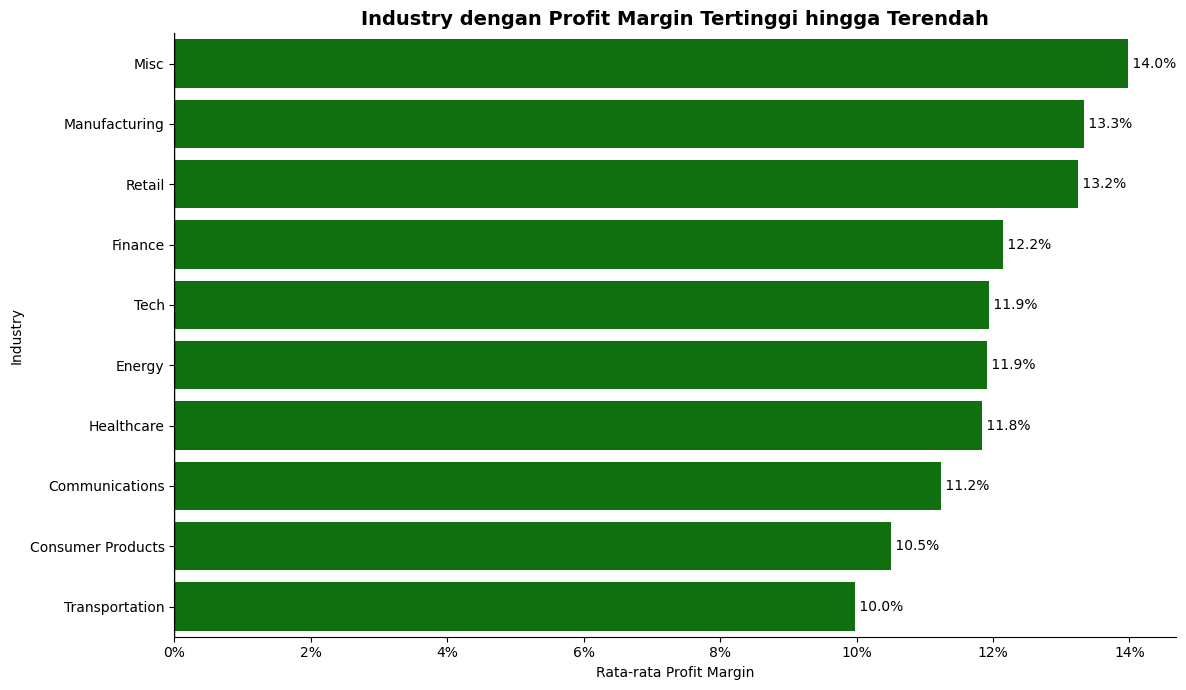

In [37]:
# Aggregation
industry_profit_margin = df.groupby('Industry')['Profit Margin'].mean().reset_index()

# Sort
industry_profit_margin = industry_profit_margin.sort_values(
    by='Profit Margin', ascending=False
)

# Warna berdasarkan value
colors = ['green' if x > 0 else 'red' for x in industry_profit_margin['Profit Margin']]

# Formatter persen
def percent_format(x, pos):
    return f'{x:.0%}'

# Plot
plt.figure(figsize=(12, 7))

sns.barplot(
    x='Profit Margin',
    y='Industry',
    data=industry_profit_margin,
    palette=colors
)

# Judul (lebih storytelling)
plt.title('Industry dengan Profit Margin Tertinggi hingga Terendah', 
          fontsize=14, weight='bold')

# Label
plt.xlabel('Rata-rata Profit Margin')
plt.ylabel('Industry')

# Format axis ke persen
plt.gca().xaxis.set_major_formatter(FuncFormatter(percent_format))

# Garis tengah (0) untuk highlight rugi vs untung
plt.axvline(0, color='black', linewidth=1)

# Annotasi
for i, v in enumerate(industry_profit_margin['Profit Margin']):
    plt.text(v, i, f' {v:.1%}', va='center')

sns.despine()
plt.tight_layout()

plt.show()

Interpretasi:

- Meskipun `Misc` memiliki margin tertinggi, kontribusi revenue-nya terlalu rendah (hanya sekitar 28K dalam sales).
- `Manufacturing` dan `Retail` menunjukkan profit margin yang tinggi.
- Sebaliknya, `Consumer Products` dan `Transportation` memiliki margin yang lemah.
- Sementara itu, `Finance`, `Tech`, `Energy`, dan `Healthcare` berada pada tingkat margin yang cukup baik atau rata-rata.

Interpretasi untuk Industry:

- `Finance` merupakan pasar terbesar, namun bukan yang paling efisien dari sisi margin.
- `Manufacturing` menunjukkan kombinasi yang baik antara revenue dan margin yang kuat.
- `Transportation` berkinerja kurang baik baik dari sisi sales maupun profit margin.

Insight `Segment` dan `Industry`:

Analisis karakteristik pelanggan menunjukkan perbedaan yang jelas dalam profitabilitas baik berdasarkan `Segment` maupun `Industry`. `SMB` merupakan **sumber revenue terbesar perusahaan**, namun memiliki **`Profit Margin` terendah**, yang mengindikasikan adanya tekanan harga (pricing pressure) atau ketergantungan pada transaksi dengan diskon tinggi. Sebaliknya, pelanggan Enterprise, meskipun jumlahnya lebih sedikit, memberikan **average margin tertinggi**, menunjukkan stabilitas harga yang lebih baik dan transaksi yang lebih menguntungkan.

Kinerja pada tingkat `Industry` juga menunjukkan variasi signifikan. `Finance` merupakan **kontributor revenue terbesar**, sedangkan `Manufacturing` dan `Retail` mencapai **`profit margin` tertinggi**. Di sisi lain, `Consumer Products` dan `Transportation` menunjukkan **kombinasi revenue rendah dan margin lemah**, menandakan **kinerja yang kurang optimal** di pasar tersebut. Temuan ini menegaskan bahwa profil pelanggan dan tipe industri secara signifikan memengaruhi profitabilitas, sehingga harus dipertimbangkan dalam evaluasi strategi pricing dan fokus pasar.

## Analisis Penjualan & Profitabilitas Berdasarkan `Product`
Setelah menganalisis `Subregion`, `Segment` pelanggan, dan `Industry`, langkah berikutnya adalah mengevaluasi kinerja `Product` perusahaan. Setiap produk dapat berbeda secara signifikan baik dari segi volume sales maupun profitabilitas. Beberapa produk mungkin menghasilkan sales tinggi namun dengan margin rendah, sementara yang lain bisa memberikan kontribusi kerugian yang besar akibat discounting yang berlebihan atau efisiensi harga yang rendah.

Analisis ini bertujuan untuk menjawab pertanyaan bisnis berikut:

"`Product` apa saja yang menghasilkan loss atau profit rendah meskipun memiliki sales tinggi?"

### Total `Sales` dan `Profit` Berdasarkan `Product`

In [38]:
product = df.groupby('Product')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
product

,Sales,Profit
Product,,
ContactMatcher,410378.2650,12496.2822
FinanceHub,340935.4150,32136.4203
Site Analytics,330007.0540,44515.7306
Marketing Suite - Gold,223843.6080,21278.8264
Big Ol Database,189238.6310,3384.7569
Data Smasher,167380.3180,41936.6357
Alchemy,149528.0300,55617.8249
Support,125152.7440,32864.4698
Marketing Suite,114879.9963,-3472.5560


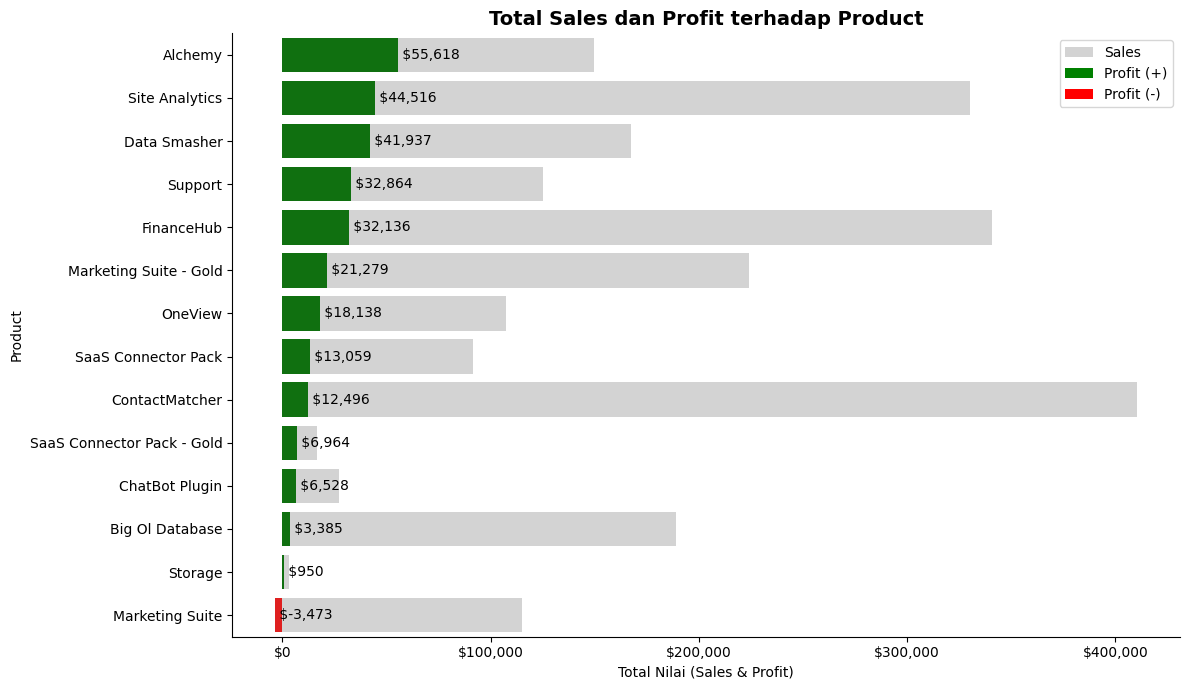

In [39]:
# Aggregation
agg_df = df.groupby('Product').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()

# Sort berdasarkan Profit
agg_df = agg_df.sort_values(by='Profit', ascending=False)

# Formatter dollar
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Plot
plt.figure(figsize=(12, 7))

# Barplot Sales
sns.barplot(
    x='Sales',
    y='Product',
    data=agg_df,
    color='lightgray'
)

# Warna profit
profit_colors = ['red' if x < 0 else 'green' for x in agg_df['Profit']]

# Overlay Profit
sns.barplot(
    x='Profit',
    y='Product',
    data=agg_df,
    palette=profit_colors
)

# Judul
plt.title('Total Sales dan Profit terhadap Product', fontsize=14, weight='bold')

# Label
plt.xlabel('Total Nilai (Sales & Profit)')
plt.ylabel('Product')

# Format axis jadi dollar
plt.gca().xaxis.set_major_formatter(FuncFormatter(dollar_format))

# Annotasi profit (pakai dollar)
for i, v in enumerate(agg_df['Profit']):
    plt.text(v, i, f' ${v:,.0f}', va='center')

# Custom legend
legend_elements = [
    Patch(facecolor='lightgray', label='Sales'),
    Patch(facecolor='green', label='Profit (+)'),
    Patch(facecolor='red', label='Profit (-)')
]

plt.legend(handles=legend_elements)

sns.despine()
plt.tight_layout()

Interpretasi:

- Tiga produk dengan **sales tertinggi** adalah `ContactMatcher`, `FinanceHub`, dan `Site Analytics`.
- Sementara itu, produk dengan **sales terendah** adalah `Storage`, `SaaS Connector Pack - Gold`, dan `ChatBot Plugin`.

### Rata-Rata `Profit Margin` Berdasarkan `Product`

In [40]:
product_profit_margin = df.groupby('Product')['Profit Margin'].mean().sort_values(ascending=False)
product_profit_margin

Product
SaaS Connector Pack - Gold    0.423140
Support                       0.387410
Alchemy                       0.317194
Storage                       0.299171
ChatBot Plugin                0.251646
Data Smasher                  0.218210
FinanceHub                    0.187037
SaaS Connector Pack           0.137066
Site Analytics                0.119222
Marketing Suite - Gold        0.089113
Big Ol Database              -0.072026
Marketing Suite              -0.126640
OneView                      -0.156869
ContactMatcher               -0.190612
Name: Profit Margin, dtype: float64

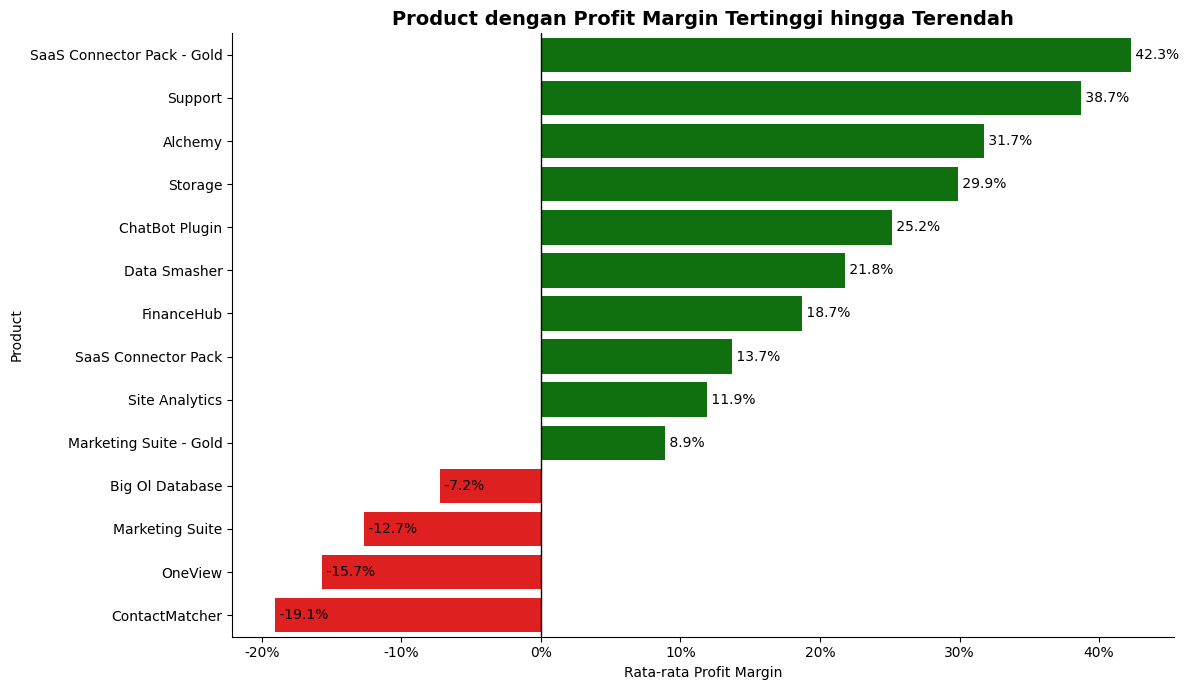

In [41]:
# Aggregation
product_profit_margin = df.groupby('Product')['Profit Margin'].mean().reset_index()

# Sort
product_profit_margin = product_profit_margin.sort_values(
    by='Profit Margin', ascending=False
)

# Warna berdasarkan value
colors = ['green' if x > 0 else 'red' for x in product_profit_margin['Profit Margin']]

# Formatter persen
def percent_format(x, pos):
    return f'{x:.0%}'

# Plot
plt.figure(figsize=(12, 7))

sns.barplot(
    x='Profit Margin',
    y='Product',
    data=product_profit_margin,
    palette=colors
)

# Judul (lebih storytelling)
plt.title('Product dengan Profit Margin Tertinggi hingga Terendah', 
          fontsize=14, weight='bold')

# Label
plt.xlabel('Rata-rata Profit Margin')
plt.ylabel('Product')

# Format axis ke persen
plt.gca().xaxis.set_major_formatter(FuncFormatter(percent_format))

# Garis tengah (0) untuk highlight rugi vs untung
plt.axvline(0, color='black', linewidth=1)

# Annotasi
for i, v in enumerate(product_profit_margin['Profit Margin']):
    plt.text(v, i, f' {v:.1%}', va='center')

sns.despine()
plt.tight_layout()

plt.show()

Interpretasi:

- `SaaS Connector Pack – Gold` memiliki margin tertinggi, namun `Sales` sangat rendah. Hal yang sama berlaku untuk `Support`.
- `Alchemy`, `Data Smasher`, dan `FinanceHub` menunjukkan kombinasi `Profit Margin` dan `Sales` yang baik.
- Sebaliknya, `ContactMatcher`, `Marketing Suite`, `OneView`, dan `Big Ol Database` memiliki `Profit Margin` **negatif**

### Identifikasi `Product` yang Bermasalah
Sekarang, setelah kita memiliki data `Sales`, `Profit`, dan `Profit Margin`, mari kita sajikan ketiganya secara berdampingan agar lebih mudah mengidentifikasi `Product` mana yang bermasalah.
Dengan menempatkan metrics ini secara paralel, kita bisa melihat kombinasi sales tinggi tapi profit rendah, atau margin negatif, sehingga fokus perbaikan bisa diarahkan pada produk yang paling berdampak terhadap kerugian.

In [42]:
product_summary = df.groupby('Product').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Profit Margin': 'mean'
}).sort_values('Sales', ascending=False)
product_summary

,Sales,Profit,Profit Margin
Product,,,
ContactMatcher,410378.2650,12496.2822,-0.190612
FinanceHub,340935.4150,32136.4203,0.187037
Site Analytics,330007.0540,44515.7306,0.119222
Marketing Suite - Gold,223843.6080,21278.8264,0.089113
Big Ol Database,189238.6310,3384.7569,-0.072026
Data Smasher,167380.3180,41936.6357,0.218210
Alchemy,149528.0300,55617.8249,0.317194
Support,125152.7440,32864.4698,0.387410
Marketing Suite,114879.9963,-3472.5560,-0.126640


Untuk mengidentifikasi produk yang paling bermasalah, digunakan filter untuk memilih produk dengan Sales di atas median namun Profit Margin di bawah median. Produk-produk ini menghasilkan revenue yang signifikan, tetapi tidak mengonversi sales menjadi profit secara efisien. Dengan kata lain, produk ini terlihat sukses dari sisi penjualan, namun justru merugikan profitabilitas.

In [43]:
problem_product = product_summary[(product_summary['Sales'] > product_summary['Sales'].median()) & 
                                (product_summary['Profit Margin'] < product_summary['Profit Margin'].median())]

problem_product

,Sales,Profit,Profit Margin
Product,,,
ContactMatcher,410378.265,12496.2822,-0.190612
Site Analytics,330007.054,44515.7306,0.119222
Marketing Suite - Gold,223843.608,21278.8264,0.089113
Big Ol Database,189238.631,3384.7569,-0.072026


Interpretasi:

Filter tersebut mengidentifikasi empat produk utama yang menjadi red-flag:

- `ContactMatcher` — produk dengan sales tertinggi, namun memiliki profit margin negatif (−19%) dan menghasilkan hanya 12K profit dari 410K dalam salesnya. Hal ini menunjukkan ketidakefisienan harga yang serius atau discounting yang berat.
- `Site Analytics` — kontributor revenue utama dengan sales sebesar 330K, namun average margin hanya 12%. Meskipun masih menghasilkan profit, margin-nya jauh di bawah median portofolio, menandakan adanya tekanan harga pada produk ini.
- `Marketing Suite – Gold` — menghasilkan sales tinggi (lebih dari 223K), namun margin kurang dari 10%. Produk ini memberikan kontribusi signifikan terhadap revenue, tetapi relatif sedikit terhadap profit.
- `Big Ol Database` — meskipun menghasilkan 3K dalam profit dari 190K dalam salesnya, memiliki margin negatif. Produk ini berkinerja buruk dibandingkan volume revenue-nya.

Temuan ini menyoroti bahwa produk yang paling berisiko secara finansial bukanlah produk dengan sales rendah, melainkan beberapa top performer dari sisi penjualan. Fokus pada strategi harga (pricing strategy), pengendalian diskon (discount controls), atau desain produk pada penawaran ini dapat secara signifikan meningkatkan profitabilitas perusahaan secara keseluruhan.

### Visualisasi `Sales` dan `Profit` Berdasarkan `Product`

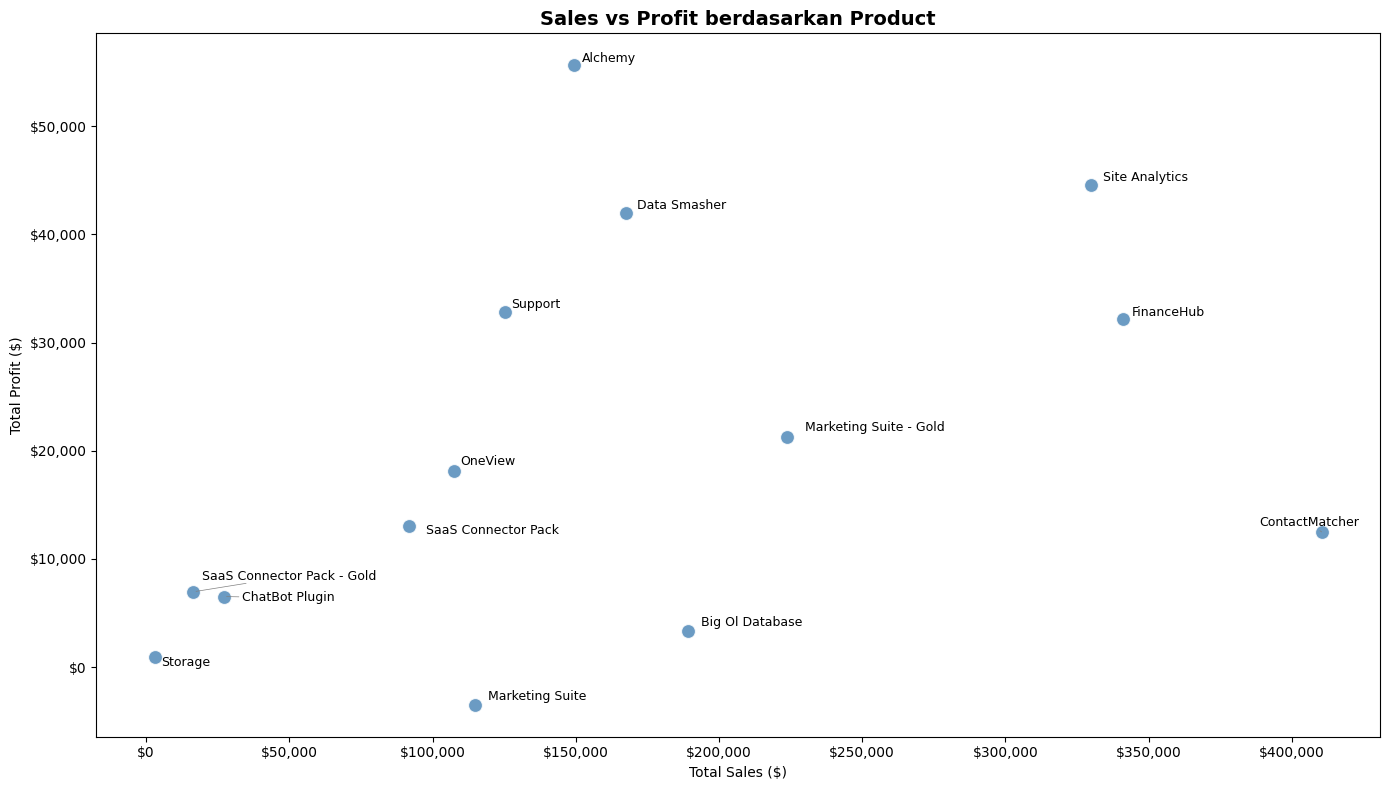

In [44]:
# Formatter dollar
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Plot
plt.figure(figsize=(14, 8))

ax = sns.scatterplot(
    data=product_summary,
    x='Sales',
    y='Profit',
    color='steelblue',
    s=100,
    alpha=0.8
)

# Tambahkan label semua produk
texts = []
for product, row in product_summary.iterrows():
    texts.append(
        plt.text(row['Sales'], row['Profit'], product, fontsize=9)
    )

# Rapikan label agar tidak tumpang tindih
adjust_text(
    texts,
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5)
)

# Format axis ke dollar
ax.xaxis.set_major_formatter(FuncFormatter(dollar_format))
ax.yaxis.set_major_formatter(FuncFormatter(dollar_format))

# Judul & label
plt.title("Sales vs Profit berdasarkan Product", fontsize=14, weight='bold')
plt.xlabel("Total Sales ($)")
plt.ylabel("Total Profit ($)")

plt.tight_layout()
plt.show()

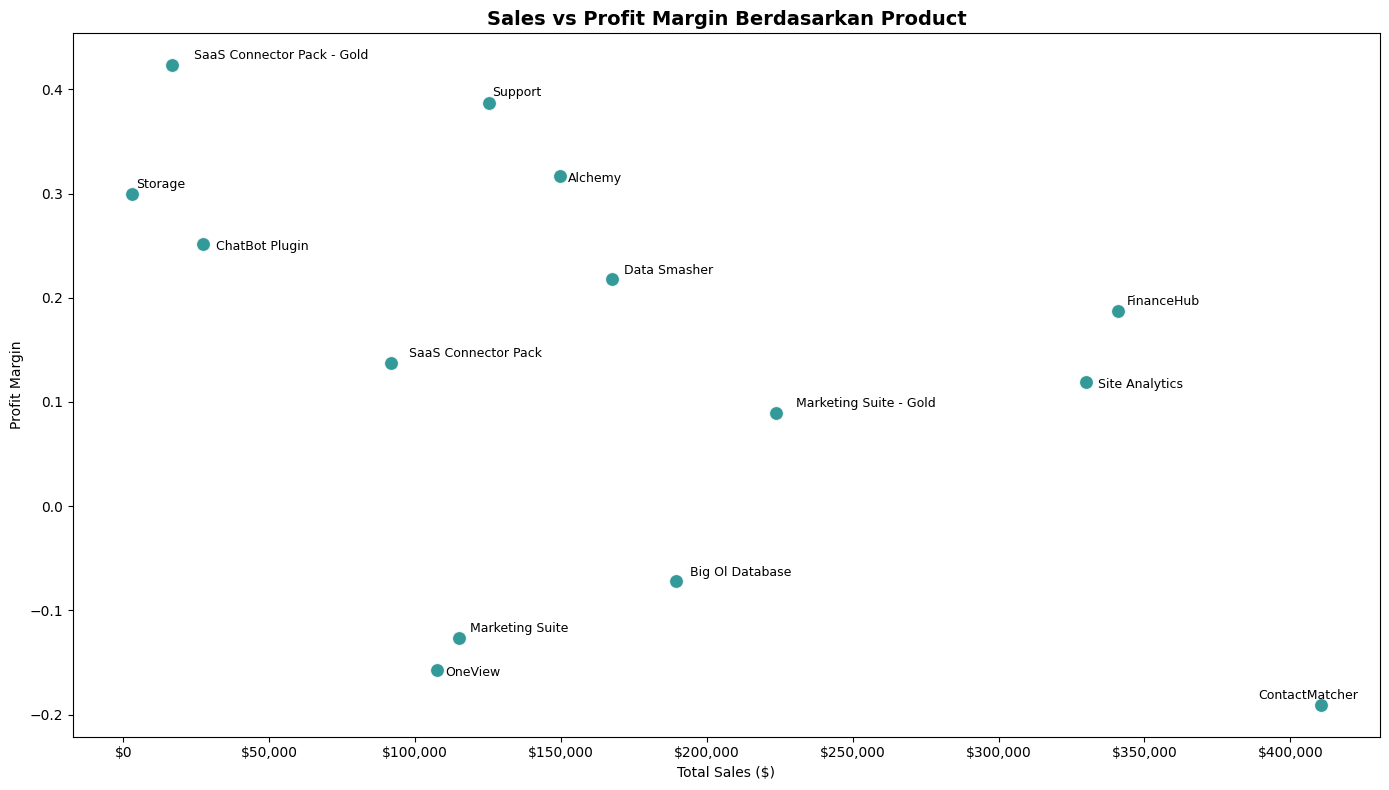

In [45]:
# Plot
plt.figure(figsize=(14, 8))

ax = sns.scatterplot(
    data=product_summary,
    x='Sales',
    y='Profit Margin',
    color='teal',
    s=100,
    alpha=0.8
)

# Tambahkan label produk (pastikan Product kolom, bukan index)
texts = []
for product, row in product_summary.iterrows():
    texts.append(
        plt.text(row['Sales'], row['Profit Margin'], product, fontsize=9)
    )

# Rapikan label
adjust_text(
    texts,
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5)
)

# Format sumbu Sales jadi dollar
ax.xaxis.set_major_formatter(FuncFormatter(dollar_format))

# Judul & label
plt.title("Sales vs Profit Margin Berdasarkan Product", fontsize=14, weight='bold')
plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin")

plt.tight_layout()
plt.show()

Interpretasi:

Scatter plot menunjukkan bahwa tidak semua produk dengan revenue tinggi menghasilkan profit yang besar. Produk seperti `Alchemy`, `Data Smasher`, `Support`, `FinanceHub`, dan `Site Analytics` memang memberikan profit yang kuat, tetapi beberapa produk top-selling justru berkinerja buruk dari sisi profitabilitas. Secara khusus, `ContactMatcher`, `Marketing Suite – Gold`, dan `Big Ol Database` menghasilkan sales tinggi, namun memberikan profit yang relatif rendah. Hal ini menunjukkan bahwa popularitas sebuah produk tidak selalu sejalan dengan kinerja finansial, dan beberapa produk dengan volume tinggi mungkin mengalami discounting berlebihan atau strategi harga yang tidak efisien.

Hubungan antara penjualan dan profit margin menunjukkan perbedaan yang jelas dalam efisiensi penetapan harga. Produk dengan margin tinggi seperti `SaaS Connector Pack – Gold`, `Support`, `Alchemy`, `Storage`, dan `ChatBot Plugin` mampu menghasilkan profit yang kuat meskipun volume penjualannya relatif rendah. Sebaliknya, beberapa produk dengan pendapatan tinggi seperti `ContactMatcher`, `OneView`, `Big Ol Database`, dan `Marketing Suite` justru memiliki margin profit yang sangat rendah atau bahkan negatif, yang mengindikasikan adanya ketidakefisienan harga atau pemberian diskon yang berlebihan. Produk-produk ini termasuk dalam kategori “high sales, low margin” yang berisiko, sehingga perlu menjadi prioritas utama untuk evaluasi strategi pricing.

Insight Product:

Analisis kinerja produk menunjukkan adanya variasi yang cukup signifikan dalam hal pendapatan dan profitabilitas di seluruh portofolio perusahaan. Beberapa produk, seperti `ContactMatcher`, `FinanceHub`, dan `Site Analytics`, berperan sebagai kontributor utama terhadap pendapatan dan memberikan kontribusi besar terhadap total penjualan. Namun demikian, analisis lebih lanjut terhadap profit dan profit margin mengindikasikan bahwa tingginya volume penjualan tidak selalu sejalan dengan kinerja keuangan yang optimal.

Untuk memahami perbedaan ini, dilakukan penyaringan data guna mengidentifikasi produk dengan nilai penjualan tinggi (di atas median) tetapi memiliki margin keuntungan rendah (di bawah median). Kelompok produk dengan karakteristik tersebut menjadi perhatian utama karena meskipun menghasilkan porsi pendapatan yang besar, kontribusi keuntungannya relatif tidak sebanding.

Hasil penyaringan tersebut mengidentifikasi empat produk utama yang bermasalah, yaitu `ContactMatcher`, `Site Analytics`, `Marketing Suite – Gold`, dan `Big Ol Database`. Temuan ini menunjukkan bahwa risiko finansial terbesar perusahaan bukan berasal dari produk dengan penjualan rendah, melainkan dari beberapa produk yang justru memiliki tingkat permintaan tinggi. Kombinasi antara tingginya permintaan dan rendahnya margin mengindikasikan adanya potensi masalah, seperti strategi diskon yang terlalu agresif, biaya operasional atau dukungan yang tinggi, maupun penetapan harga yang kurang tepat.

Sebaliknya, produk seperti `Alchemy`, `Data Smasher`, dan `FinanceHub` menunjukkan kinerja yang lebih sehat, dengan margin keuntungan yang kuat serta tetap mampu menghasilkan pendapatan yang signifikan. Produk-produk ini dapat dianggap sebagai bagian portofolio yang stabil dan efisien.

## Analisis Penjualan & Profitabilitas Berdasarkan Discount
Diskon memiliki peran yang sangat signifikan dalam kinerja penjualan SaaS. Pemberian diskon yang tinggi akan menurunkan harga jual akhir, sehingga berdampak langsung pada berkurangnya keuntungan. Pada bagian sebelumnya, ditemukan bahwa beberapa produk dan subwilayah menunjukkan margin yang rendah bahkan negatif, yang mengindikasikan bahwa strategi diskon kemungkinan menjadi salah satu penyebab utama ketidakkonsistenan profitabilitas.

Pada bagian ini, dilakukan analisis terhadap hubungan antara `Discount`, `Profit`, dan `Profit Margin`, dengan tujuan untuk menjawab *business question* berikut:

"Bagaimana pengaruh discount terhadap profit margin?"

### Korelasi antara `Discount` dan `Profit Margin`

In [46]:
df[['Discount', 'Profit Margin']].corr()

,Discount,Profit Margin
Discount,1.000000,-0.864452
Profit Margin,-0.864452,1.000000


Interpretasi:

Hasil analisis korelasi menunjukkan adanya hubungan negatif yang sangat kuat antara `Discount` dan `Profit Margin`, dengan nilai koefisien sebesar **–0,864**. Hal ini mengindikasikan bahwa **peningkatan tingkat diskon hampir selalu diikuti oleh penurunan tingkat profitabilitas**. Dalam banyak situasi, pemberian diskon yang terlalu besar dapat menekan margin keuntungan hingga mendekati nol, bahkan berpotensi menjadi negatif. Temuan ini menegaskan bahwa kebijakan diskon merupakan faktor utama yang berkontribusi terhadap ketidakstabilan serta rendahnya margin keuntungan perusahaan.

### Visualisasi Distribusi Profit Margin Berdasarkan Discount

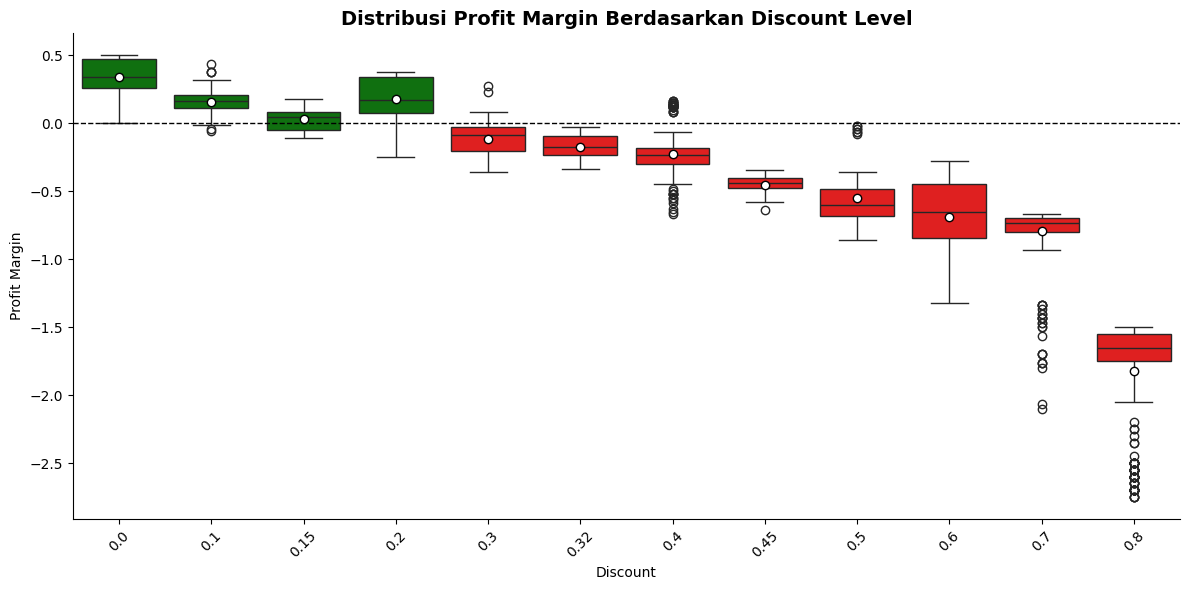

In [47]:
# Urutkan berdasarkan median profit margin
order = df.groupby('Discount')['Profit Margin'].median().index

# Warna berdasarkan median
median_values = df.groupby('Discount')['Profit Margin'].median()
colors = ['green' if median_values[sub] > 0 else 'red' for sub in order]

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='Discount',
    y='Profit Margin',
    order=order,
    palette=colors,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 6
    }
)

# Garis break-even
plt.axhline(0, color='black', linestyle='--', linewidth=1)

# Judul lebih storytelling
plt.title('Distribusi Profit Margin Berdasarkan Discount Level',
          fontsize=14, weight='bold')

# Label
plt.xlabel('Discount')
plt.ylabel('Profit Margin')

# Rotasi label
plt.xticks(rotation=45)

sns.despine()
plt.tight_layout()

Interpretasi:

- Seiring dengan meningkatnya tingkat diskon, profitabilitas cenderung mengalami penurunan. Pada tingkat diskon yang sangat tinggi, seperti 80%, margin keuntungan umumnya berada pada posisi negatif dan disertai dengan banyak nilai ekstrem (outlier) yang juga negatif.
- Diskon pada kisaran 10–20% masih tergolong terkendali, di mana median margin keuntungan tetap berada pada level positif dan sebaran datanya relatif tidak terlalu lebar.
- Sementara itu, tanpa pemberian diskon (0%), Profit Margin menunjukkan kinerja terbaik, dengan nilai minimum setidaknya berada pada titik impas (break-even).

### Rata-Rata Discount Berdasarkan Subregion, Segment, Industry dan Product

**Subregion**

In [48]:
subregion_discount = df.groupby('Subregion')['Discount'].mean().sort_values(ascending=False)
subregion_discount

Subregion
JAPN       0.370193
ANZ        0.366919
EU-WEST    0.213662
LATAM      0.192401
EU-EAST    0.175802
NOR        0.146830
MEA        0.144192
NAMER      0.071001
UKIR       0.049250
APAC       0.011409
EU         0.000000
IND        0.000000
Name: Discount, dtype: float64

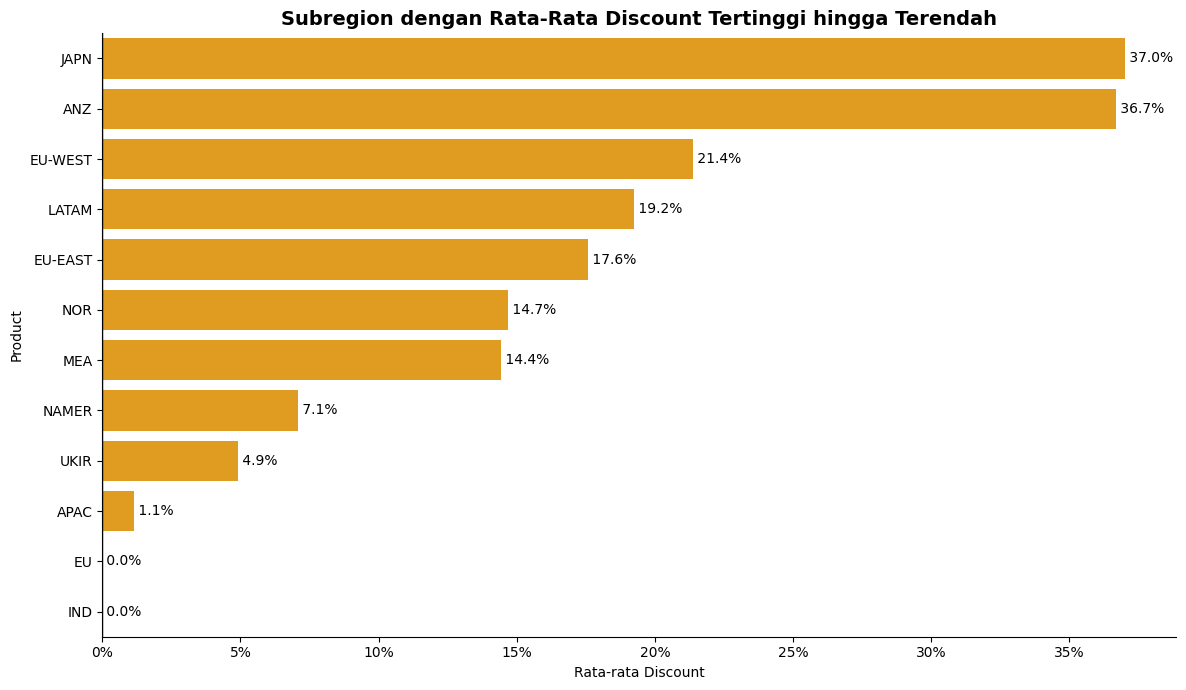

In [49]:
# Aggregation
subregion_discount = df.groupby('Subregion')['Discount'].mean().reset_index()

# Sort
subregion_discount = subregion_discount.sort_values(
    by='Discount', ascending=False
)

# Warna berdasarkan value
colors = ['orange' if x > 0 else 'red' for x in subregion_discount['Discount']]

# Formatter persen
def percent_format(x, pos):
    return f'{x:.0%}'

# Plot
plt.figure(figsize=(12, 7))

sns.barplot(
    x='Discount',
    y='Subregion',
    data=subregion_discount,
    palette=colors
)

# Judul (lebih storytelling)
plt.title('Subregion dengan Rata-Rata Discount Tertinggi hingga Terendah', 
          fontsize=14, weight='bold')

# Label
plt.xlabel('Rata-rata Discount')
plt.ylabel('Product')

# Format axis ke persen
plt.gca().xaxis.set_major_formatter(FuncFormatter(percent_format))

# Garis tengah (0) untuk highlight rugi vs untung
plt.axvline(0, color='black', linewidth=1)

# Annotasi
for i, v in enumerate(subregion_discount['Discount']):
    plt.text(v, i, f' {v:.1%}', va='center')

sns.despine()
plt.tight_layout()

plt.show()

Interpretasi:

- Wilayah `JAPN` dan `ANZ` memperoleh tingkat diskon tertinggi, yang berdampak pada rata-rata margin keuntungan yang negatif.
- Sebaliknya, wilayah `IND` dan `EU` tidak menerima diskon sama sekali.
- Sementara itu, `NAMER`, `UKIR`, dan `APAC` hanya mendapatkan diskon dalam jumlah relatif kecil, yang berkontribusi pada tingginya margin keuntungan di wilayah tersebut.

**Segment**

In [50]:
segment_discount = df.groupby('Segment')['Discount'].mean().sort_values(ascending=False)
segment_discount

Segment
Strategic     0.158228
SMB           0.158141
Enterprise    0.147128
Name: Discount, dtype: float64

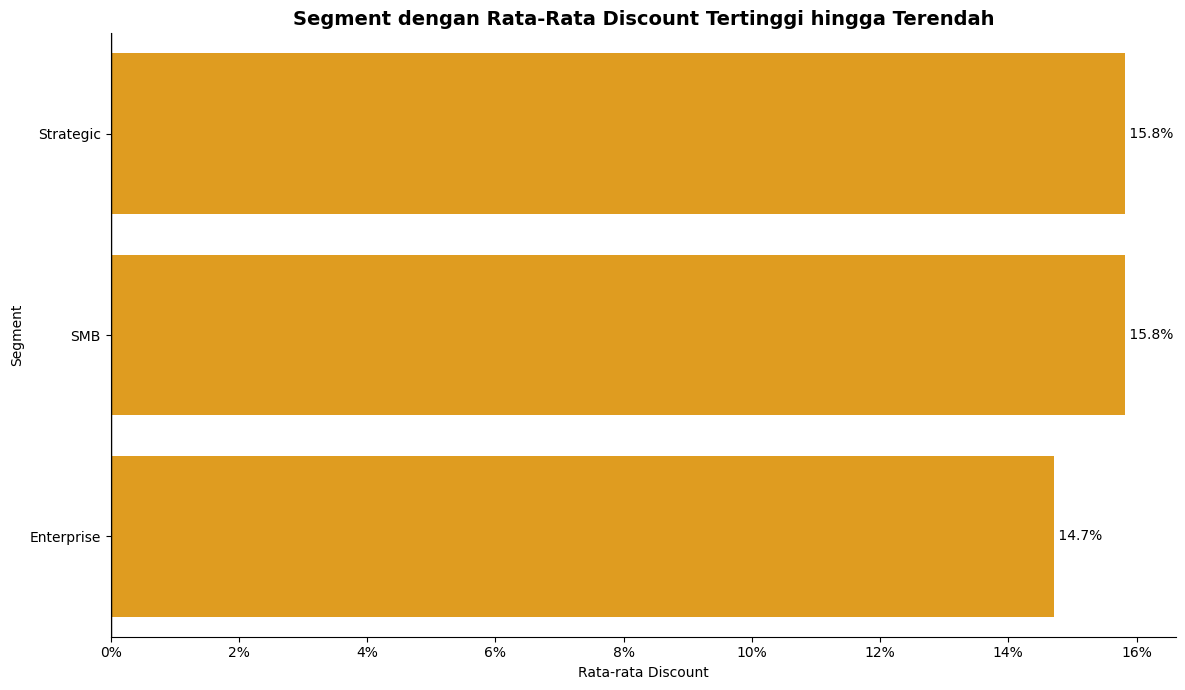

In [51]:
# Aggregation
segment_discount = df.groupby('Segment')['Discount'].mean().reset_index()

# Sort
segment_discount = segment_discount.sort_values(
    by='Discount', ascending=False
)

# Warna berdasarkan value
colors = ['orange' if x > 0 else 'red' for x in segment_discount['Discount']]

# Formatter persen
def percent_format(x, pos):
    return f'{x:.0%}'

# Plot
plt.figure(figsize=(12, 7))

sns.barplot(
    x='Discount',
    y='Segment',
    data=segment_discount,
    palette=colors
)

# Judul (lebih storytelling)
plt.title('Segment dengan Rata-Rata Discount Tertinggi hingga Terendah', 
          fontsize=14, weight='bold')

# Label
plt.xlabel('Rata-rata Discount')
plt.ylabel('Segment')

# Format axis ke persen
plt.gca().xaxis.set_major_formatter(FuncFormatter(percent_format))

# Garis tengah (0) untuk highlight rugi vs untung
plt.axvline(0, color='black', linewidth=1)

# Annotasi
for i, v in enumerate(segment_discount['Discount']):
    plt.text(v, i, f' {v:.1%}', va='center')

sns.despine()
plt.tight_layout()

plt.show()

Interpretasi:

Segmen `Enterprise` menerima tingkat diskon yang relatif lebih rendah, yang selaras dengan pencapaian margin keuntungan yang lebih tinggi.

**Industry**

In [52]:
industry_discount = df.groupby('Industry')['Discount'].mean().sort_values(ascending=False)
industry_discount

Industry
Communications       0.164165
Consumer Products    0.162586
Energy               0.159947
Tech                 0.159094
Transportation       0.157179
Manufacturing        0.155385
Healthcare           0.155091
Finance              0.153644
Retail               0.145113
Misc                 0.140374
Name: Discount, dtype: float64

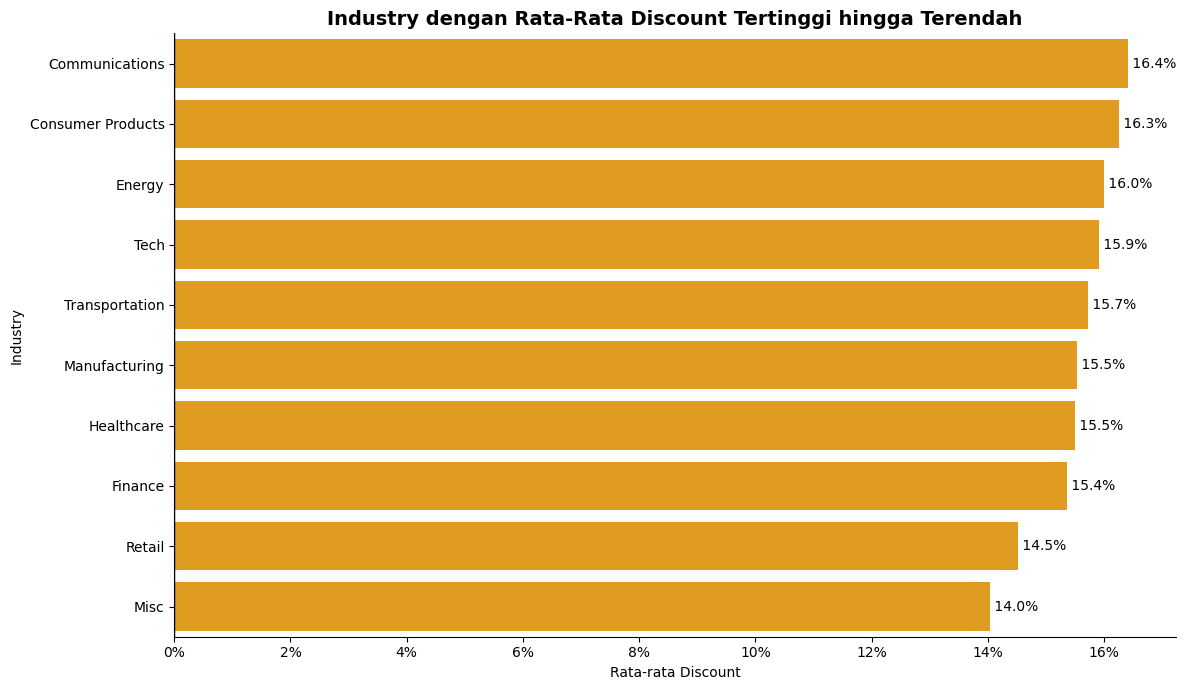

In [53]:
# Aggregation
industry_discount = df.groupby('Industry')['Discount'].mean().reset_index()

# Sort
industry_discount = industry_discount.sort_values(
    by='Discount', ascending=False
)

# Warna berdasarkan value
colors = ['orange' if x > 0 else 'red' for x in industry_discount['Discount']]

# Formatter persen
def percent_format(x, pos):
    return f'{x:.0%}'

# Plot
plt.figure(figsize=(12, 7))

sns.barplot(
    x='Discount',
    y='Industry',
    data=industry_discount,
    palette=colors
)

# Judul (lebih storytelling)
plt.title('Industry dengan Rata-Rata Discount Tertinggi hingga Terendah', 
          fontsize=14, weight='bold')

# Label
plt.xlabel('Rata-rata Discount')
plt.ylabel('Industry')

# Format axis ke persen
plt.gca().xaxis.set_major_formatter(FuncFormatter(percent_format))

# Garis tengah (0) untuk highlight rugi vs untung
plt.axvline(0, color='black', linewidth=1)

# Annotasi
for i, v in enumerate(industry_discount['Discount']):
    plt.text(v, i, f' {v:.1%}', va='center')

sns.despine()
plt.tight_layout()

plt.show()

Interpretasi:

- Sektor seperti `Communications` dan `Consumer Products` menunjukkan kebutuhan akan tingkat diskon yang paling tinggi.
- Sebaliknya, sektor `Retail` dan `Finance` menerima diskon yang relatif lebih rendah, yang turut mendukung pencapaian margin keuntungan yang lebih tinggi.

**Product**

In [54]:
product_discount = df.groupby('Product')['Discount'].mean().sort_values(ascending=False)
product_discount

Product
ContactMatcher                0.353067
Big Ol Database               0.306087
Marketing Suite               0.211140
OneView                       0.166524
Alchemy                       0.161765
Site Analytics                0.154556
SaaS Connector Pack           0.138349
FinanceHub                    0.132518
Storage                       0.082028
SaaS Connector Pack - Gold    0.080315
Data Smasher                  0.078452
Support                       0.075128
ChatBot Plugin                0.074874
Marketing Suite - Gold        0.074704
Name: Discount, dtype: float64

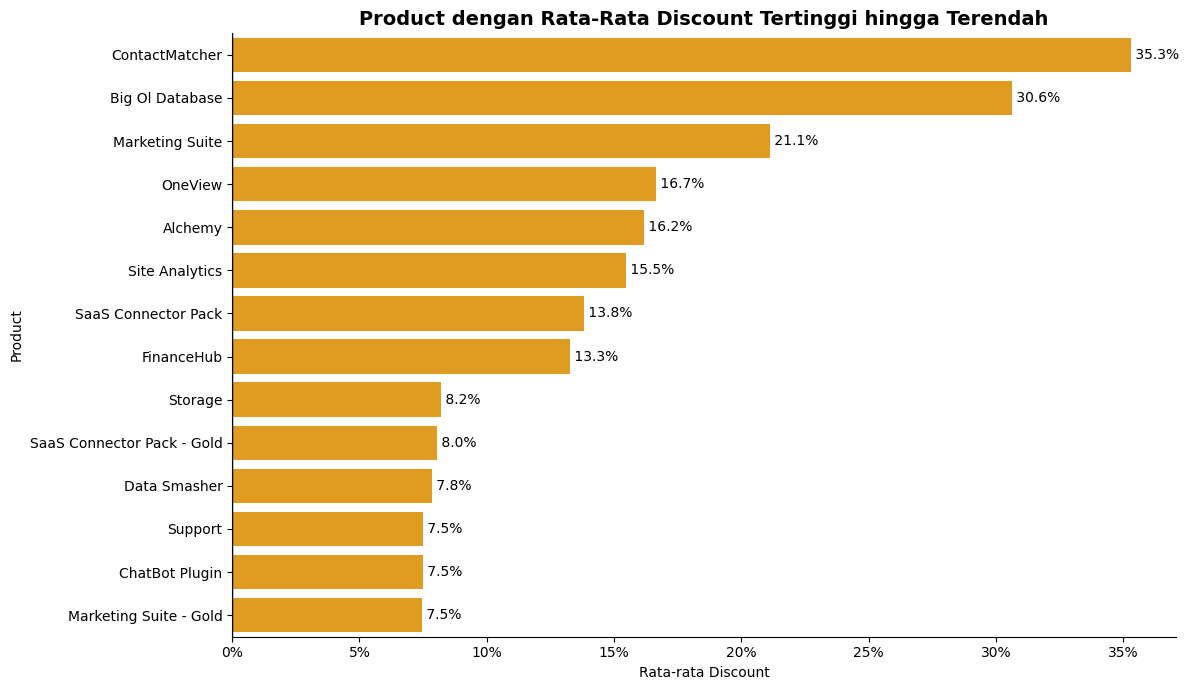

In [55]:
# Aggregation
product_discount = df.groupby('Product')['Discount'].mean().reset_index()

# Sort
product_discount = product_discount.sort_values(
    by='Discount', ascending=False
)

# Warna berdasarkan value
colors = ['orange' if x > 0 else 'red' for x in product_discount['Discount']]

# Formatter persen
def percent_format(x, pos):
    return f'{x:.0%}'

# Plot
plt.figure(figsize=(12, 7))

sns.barplot(
    x='Discount',
    y='Product',
    data=product_discount,
    palette=colors
)

# Judul (lebih storytelling)
plt.title('Product dengan Rata-Rata Discount Tertinggi hingga Terendah', 
          fontsize=14, weight='bold')

# Label
plt.xlabel('Rata-rata Discount')
plt.ylabel('Product')

# Format axis ke persen
plt.gca().xaxis.set_major_formatter(FuncFormatter(percent_format))

# Garis tengah (0) untuk highlight rugi vs untung
plt.axvline(0, color='black', linewidth=1)

# Annotasi
for i, v in enumerate(product_discount['Discount']):
    plt.text(v, i, f' {v:.1%}', va='center')

sns.despine()
plt.tight_layout()

plt.show()

Interpretasi:

- Produk dengan tingkat diskon tertinggi mencakup ContactMatcher, Big Ol Database, dan Marketing Suite, yang tergolong sebagai produk dengan kinerja kurang optimal.
- Sementara itu, Alchemy, FinanceHub, dan Data Smasher menerima diskon pada tingkat sedang hingga rendah, serta menunjukkan margin keuntungan yang baik.

Insight Discount:

Analisis diskon menunjukkan bahwa pemberian diskon merupakan faktor utama yang secara konsisten menekan profitabilitas perusahaan.

Terdapat korelasi negatif yang sangat kuat antara diskon dan margin keuntungan (–0,864), di mana peningkatan diskon secara signifikan menurunkan margin, bahkan menjadi negatif. Pada tingkat diskon di atas 40–50%, mayoritas transaksi menghasilkan kerugian, menandakan bahwa diskon yang terlalu agresif berdampak langsung pada penurunan profit.

Perbedaan pola diskon juga terlihat antar segmen dan industri. Pelanggan Strategic dan SMB menerima diskon tertinggi, sementara Enterprise menerima lebih rendah dan memiliki margin lebih baik. Industri seperti Communications dan Consumer Products cenderung memiliki diskon tinggi dan margin rendah, sedangkan Retail dan Finance menunjukkan kondisi sebaliknya.

Dari sisi wilayah, JAPN dan ANZ memiliki diskon tinggi dengan margin negatif, sementara IND tanpa diskon justru mencatat margin tinggi. Pada tingkat produk, item dengan diskon tinggi cenderung memiliki margin rendah, sedangkan produk dengan diskon rendah menunjukkan profitabilitas yang lebih baik.

Secara keseluruhan, pengelolaan diskon yang lebih strategis diperlukan untuk meningkatkan profitabilitas perusahaan secara menyeluruh.

# Kesimpulan dan Rekomendasi 

**Kesimpulan Temuan**

**Tren Penjualan dan Profit**
- Tren pertumbuhan yang positif ditunjukkan oleh penjualan dan profit perusahaan dari tahun ke tahun dan lonjakan signifikan terjadi pada tahun 2023.
- Rata-rata puncak penjualan dan profit terjadi di akhir tahun (Q4), menandakan kemungkinan adanya pola musiman yang kuat seperti pengaruh strategi promosi dan pembelanjaan akhir tahun oleh customer.
- Walaupun hampir keseluruhan bulan menghasilkan profit positif, terdapat beberapa periode bulan yang mengalami profit negatif terutama di awal tahun (Q1). Tetapi proporsi transaksi untung tetap stabil di kisaran 80% tiap tahunnya.
- Peningkatan signifikan penjualan tidak selalu diikuti kenaikan profit yang sebanding, mengindikasi jika perusahaan perlu menjaga margin keuntungan di tengah peningkatan volume penjualan.

**Subregion**

- Subregion seperti `IND`, `UKIR`, dan `NAMER` menunjukkan margin keuntungan yang kuat dan stabil, yang dipengaruhi oleh tingkat diskon rata-rata yang lebih rendah.
- Sebaliknya, `JAPN` dan `ANZ` memperlihatkan fluktuasi margin yang tinggi serta sering mengalami margin negatif, yang disebabkan oleh pemberian diskon yang sangat tinggi.

**Segment dan Industry**

- Pelanggan segmen `Enterprise` menerima tingkat diskon yang lebih rendah dan mampu menghasilkan margin keuntungan yang lebih tinggi.
- Sebaliknya, segmen `Strategic` dan `SMB` memperoleh diskon yang lebih besar, sehingga berdampak pada margin yang lebih rendah meskipun memberikan kontribusi penjualan yang tinggi.
- Selain itu, industri seperti `Communications`, `Consumer Products`, `Energy`, dan `Tech` cenderung lebih sensitif terhadap harga, sehingga lebih sering membutuhkan diskon dalam jumlah yang lebih besar.

**Product**

- Beberapa produk dengan pendapatan tinggi seperti `ContactMatcher`, `Site Analytics`, `Marketing Suite – Gold`, dan `Big Ol Database` menunjukkan margin keuntungan yang sangat rendah bahkan negatif. Produk-produk ini termasuk dalam kategori “high sales but low margin” yang berisiko, sehingga menjadi prioritas utama untuk pengendalian harga maupun kebijakan diskon.
- Sebaliknya, produk seperti `Alchemy`, `Data Smasher`, `Support`, dan `FinanceHub` mampu mempertahankan margin yang kuat, sehingga dapat dikategorikan sebagai penawaran yang lebih efisien dan menguntungkan.

**Discount**

- Pemberian diskon menunjukkan korelasi negatif yang sangat kuat dengan margin keuntungan (–0,864).
- Tingkat diskon yang lebih tinggi secara konsisten menghasilkan margin yang lebih rendah atau bahkan negatif.
- Saat diskon melebihi 30%, margin menjadi sangat tidak stabil dan sering kali negatif, menimbulkan risiko keuangan yang signifikan.

## Konklusi
Analisis menyimpulkan bahwa penyebab utama ketidakstabilan profitabilitas adalah pemberian diskon yang agresif dan tidak merata di berbagai wilayah, segmen pelanggan, industri, dan produk. Bahkan produk atau wilayah dengan pendapatan tinggi bisa mengalami kinerja rendah jika diskon terlalu besar, sedangkan pasar dengan diskon rendah cenderung mempertahankan margin yang sehat.

Untuk meningkatkan profitabilitas, perusahaan perlu mengadopsi pendekatan diskon yang lebih strategis dan berbasis data. Perbaikan efisiensi harga, pengetatan batas diskon, dan fokus pada produk dengan margin tinggi akan memberikan dampak signifikan terhadap hasil keuangan.

## Rekomendasi

1. Strategi Optimisasi Penjualan dan Profit Tahunan
- Prioritaskan strategi promosi dan penjualan pada akhir tahun guna mengoptimalkan peluang peningkatan sales dan profit.
- Lakukan peninjauan pada periode awal tahun yang mengalami kerugian, misalnya dengan membatasi diskon besar atau mengefisienkan biaya operasional.
- Pertahankan keseimbangan antara pertumbuhan penjualan dan profit dengan mengendalikan pemberian diskon serta menjaga margin tetap stabil.
- Lakukan pemantauan rutin terhadap tren bulanan dan tahunan untuk lebih cepat mengidentifikasi penurunan profit atau perubahan pola musiman agar strategi dapat segera disesuaikan.

2. Kontrol Pemberian Discount
- Terapkan tingkat persetujuan bertingkat untuk diskon di atas 20%, 30%, dan 40%.
- Batasi pemberian diskon lebih dari 50%, kecuali untuk kesepakatan strategis dengan justifikasi yang jelas.
- Standarisasi kebijakan diskon di seluruh subwilayah untuk mengurangi variabilitas yang tidak terkendali.

3. Tinjau Kembali Harga untuk Produk High-Sales dengan Margin Rendah, Langkah-langkah yang dapat dilakukan meliputi:
- Menyesuaikan harga daftar (list price).
- Mengurangi diskon default.
- Menata ulang tingkat produk (product tiers).
- Menggabungkan dengan produk bermargin lebih tinggi (bundling).

Fokuskan evaluasi pada produk-produk yang bermasalah antara lain:
- `ContactMatcher`
- `Site Analytics`
- `Marketing Suite – Gold`
- `Big Ol Database`

4. Fokus pada Produk Bermargin Tinggi untuk Upselling dan Promosi, Produk dengan margin tinggi, seperti `Alchemy`, `Data Smasher`, dan `Support`, sebaiknya mendapatkan:
- Peningkatan fokus pada aktivitas pemasaran.
- Promosi dalam bentuk bundling.
- Insentif penjualan bagi tim sales, Strategi ini akan mendorong adopsi yang lebih luas dan memperkuat profitabilitas keseluruhan perusahaan.

5. Strategi Penetapan Harga Berdasarkan Segmen
- Untuk segmen `SMB`, kurangi diskon dengan menghadirkan paket entry-level yang lebih terjangkau daripada memberikan potongan besar.
- Perkuat komunikasi nilai-nilai produk kepada pelanggan `Strategic` untuk mengurangi ketergantungan pada diskon.
- Dorong kontrak jangka panjang pada segmen `Enterprise`, di mana diskon sudah relatif rendah, untuk mempertahankan margin yang kuat.

6. Tinjauan Strategi Harga Berdasarkan Subregion
- Selidiki praktik diskon yang ekstrem di `JAPN` dan `ANZ`, yang memiliki korelasi kuat dengan margin negatif.
- Gunakan wawasan dari wilayah dengan diskon rendah dan margin tinggi (seperti `IND`, `NAMER`, `UKIR`) sebagai acuan atau benchmark.
- Berikan pelatihan penetapan harga kepada tim penjualan di masing-masing wilayah untuk meningkatkan konsistensi dan efektivitas strategi.

7. Pantau Pemberian Discount melalui Pelaporan Berkala
- Buat dashboard untuk memantau tingkat diskon, margin keuntungan, dan profitabilitas setiap transaksi.
- Deteksi secara real-time transaksi yang berada di bawah ambang margin yang ditetapkan.
- Lakukan tinjauan kuartalan untuk menyesuaikan strategi harga berdasarkan kinerja aktual.

Dengan menangani penyebab utama menurunnya profit akibat diskon dan menekankan disiplin harga, perusahaan dapat meningkatkan profitabilitas secara signifikan tanpa harus menambah volume penjualan. Analisis ini memberikan dasar yang jelas dan berbasis data untuk tindakan strategi penetapan harga yang dapat memperkuat kinerja keuangan jangka panjang.